## Setup for EDA and time series 

In [35]:
#pip install xgboost

In [36]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#import matplotlib.dates as mdates   #from keras.layers import LSTM, Dense


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
#from keras.callbacks import EarlyStopping
#from keras.optimizers import Adam
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
import time
import matplotlib.dates as mdates   




In [37]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [38]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [39]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
df_m = pd.read_csv('data/Result_20150101-20230716_monthly.csv')
df_m.head()

,dt_date_hour,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,geothermal_mwh,...,day_ahead_auction_volume_weighted_eur_per_mwh,intraday_continuous_volume_weighted_eur_per_mwh,intraday_continuous_30min_volume_weighted_eur_per_mwh,intraday_continuous_15min_volume_weighted_eur_per_mwh,intraday_auction_15_minutes_call_eur_per_mwh,co2_emission_allowances_auction_eur_per_tco2,gas_ncg_eur_per_tco2,mean_air_temperature_de_c,mean_sunshine_duration_de_minute,mean_precipitation_de_mm
0,2015-01-31 00:00:00+01:00,2963450.25,11800178.50,0.0,1405692.50,6387684.50,130717.25,0.0,0.0,9665.00,...,30.46,31.54,NaN,31.50,28.85,6.80,NaN,2.19,35.3,85.4
1,2015-02-28 00:00:00+01:00,2692398.25,11249758.00,0.0,1615355.25,7886900.00,145943.00,0.0,0.0,9820.75,...,36.66,37.91,NaN,37.12,36.84,7.13,NaN,0.72,88.0,22.3
2,2015-03-31 00:00:00+01:00,2935810.25,12187410.00,25511.0,1361677.50,7322739.75,152918.25,0.0,0.0,7920.75,...,30.67,33.00,NaN,32.97,31.26,6.67,NaN,5.18,139.1,55.5
3,2015-04-30 00:00:00+01:00,2845630.00,10203658.25,0.0,849546.00,5998567.50,145577.25,0.0,0.0,9943.00,...,29.04,28.64,NaN,29.27,29.51,6.98,NaN,8.42,224.5,41.4
4,2015-05-31 00:00:00+01:00,2918058.50,8934112.50,0.0,866311.50,4289877.75,143307.25,0.0,0.0,12335.00,...,25.32,26.34,NaN,25.38,24.85,7.34,NaN,12.34,187.0,51.7


In [40]:
df_m.shape

(102, 45)

In [41]:
print('df_ms_hape=',df_m.shape)

df_ms_hape= (102, 45)


In [42]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 45 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   dt_date_hour                                           102 non-null    object 
 1   biomass_mwh                                            102 non-null    float64
 2   fossil_brown_coal_mwh                                  102 non-null    float64
 3   fossil_coal_derived_gas_mwh                            102 non-null    float64
 4   fossil_gas_mwh                                         102 non-null    float64
 5   fossil_hard_coal_mwh                                   102 non-null    float64
 6   fossil_oil_mwh                                         102 non-null    float64
 7   fossil_oil_shale_mwh                                   102 non-null    float64
 8   fossil_peat_mwh                                   

In [43]:
# Cerate a working data frame
#importing data in original units 
data_dfm_mwh = df_m.copy()
#data_df_mwh.head()

#### Here we add new columns to data frame 

In [44]:
data_dfm_mwh.columns

Index(['dt_date_hour', 'biomass_mwh', 'fossil_brown_coal_mwh',
       'fossil_coal_derived_gas_mwh', 'fossil_gas_mwh', 'fossil_hard_coal_mwh',
       'fossil_oil_mwh', 'fossil_oil_shale_mwh', 'fossil_peat_mwh',
       'geothermal_mwh', 'hydro_pumped_storage_aggregated_mwh',
       'hydro_pumped_storage_consumption_mwh',
       'hydro_run_of_river_and_poundage_mwh', 'hydro_water_reservoir_mwh',
       'marine_mwh', 'nuclear_mwh', 'other_mwh', 'other_renewable_mwh',
       'solar_mwh', 'waste_mwh', 'wind_offshore_mwh', 'wind_onshore_mwh',
       'total_energy_generation_mwh', 'solar_gwh',
       'total_energy_generation_gwh', 'dt_year', 'dt_month', 'dt_monthname',
       'dt_date', 'solar_twh', 'biomass_gw', 'wind_offshore_gw',
       'wind_onshore_gw', 'solar_gw', 'spot_market_price_eur_per_mwh',
       'day_ahead_auction_volume_weighted_eur_per_mwh',
       'intraday_continuous_volume_weighted_eur_per_mwh',
       'intraday_continuous_30min_volume_weighted_eur_per_mwh',
       'intrada

In [45]:

#data_dfm_mwh['diff_total_energy_and_solar_mwh'] =  data_dfm_mwh['total_energy_generation_mwh'] - data_dfm_mwh['solar_mwh']
# Total renewable energy column other than solar 
#data_dfm_mwh['total_other_renewable_mwh'] = data_dfm_mwh['wind_onshore_mwh'] + data_dfm_mwh['wind_offshore_mwh'] + data_dfm_mwh['waste_mwh']
#+ data_dfm_mwh['other_renewable_mwh'] + data_dfm_mwh['marine_mwh'] + data_dfm_mwh['hydro_run_of_river_and_poundage_mwh'] + data_dfm_mwh['hydro_water_reservoir_mwh'] + data_dfm_mwh['geothermal_mwh']
#data_dfm_mwh.head()


#### We capitalize the columns names

In [46]:
##  Capitalize the columns names
data_dfm_mwh.columns = [col.capitalize() for col in data_dfm_mwh.columns]
# Print the dataframe
data_dfm_mwh.head()

,Dt_date_hour,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,Geothermal_mwh,...,Day_ahead_auction_volume_weighted_eur_per_mwh,Intraday_continuous_volume_weighted_eur_per_mwh,Intraday_continuous_30min_volume_weighted_eur_per_mwh,Intraday_continuous_15min_volume_weighted_eur_per_mwh,Intraday_auction_15_minutes_call_eur_per_mwh,Co2_emission_allowances_auction_eur_per_tco2,Gas_ncg_eur_per_tco2,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm
0,2015-01-31 00:00:00+01:00,2963450.25,11800178.50,0.0,1405692.50,6387684.50,130717.25,0.0,0.0,9665.00,...,30.46,31.54,NaN,31.50,28.85,6.80,NaN,2.19,35.3,85.4
1,2015-02-28 00:00:00+01:00,2692398.25,11249758.00,0.0,1615355.25,7886900.00,145943.00,0.0,0.0,9820.75,...,36.66,37.91,NaN,37.12,36.84,7.13,NaN,0.72,88.0,22.3
2,2015-03-31 00:00:00+01:00,2935810.25,12187410.00,25511.0,1361677.50,7322739.75,152918.25,0.0,0.0,7920.75,...,30.67,33.00,NaN,32.97,31.26,6.67,NaN,5.18,139.1,55.5
3,2015-04-30 00:00:00+01:00,2845630.00,10203658.25,0.0,849546.00,5998567.50,145577.25,0.0,0.0,9943.00,...,29.04,28.64,NaN,29.27,29.51,6.98,NaN,8.42,224.5,41.4
4,2015-05-31 00:00:00+01:00,2918058.50,8934112.50,0.0,866311.50,4289877.75,143307.25,0.0,0.0,12335.00,...,25.32,26.34,NaN,25.38,24.85,7.34,NaN,12.34,187.0,51.7


#### Unit conversion from 'mwh' to 'gwh' 

In [47]:
data_dfm_gwh = data_dfm_mwh.copy()
data_dfm_gwh.columns

Index(['Dt_date_hour', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Total_energy_generation_mwh', 'Solar_gwh',
       'Total_energy_generation_gwh', 'Dt_year', 'Dt_month', 'Dt_monthname',
       'Dt_date', 'Solar_twh', 'Biomass_gw', 'Wind_offshore_gw',
       'Wind_onshore_gw', 'Solar_gw', 'Spot_market_price_eur_per_mwh',
       'Day_ahead_auction_volume_weighted_eur_per_mwh',
       'Intraday_continuous_volume_weighted_eur_per_mwh',
       'Intraday_continuous_30min_volume_weighted_eur_per_mwh',
       'Intrada

In [48]:
# Here we convert  unit from mwh to gwh 
#for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
#       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
#       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
#       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
#       'Hydro_pumped_storage_consumption_mwh',
#       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
#       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
#       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
#       'Total_energy_generation_mwh', 'Spot_market_price_eur_per_mwh',
#       'Day_ahead_auction_volume_weighted_eur_per_mwh',
#       'Intraday_continuous_volume_weighted_eur_per_mwh',
#       'Intraday_continuous_30min_volume_weighted_eur_per_mwh',
#       'Intraday_continuous_15min_volume_weighted_eur_per_mwh',
#       'Intraday_auction_15_minutes_call_eur_per_mwh']:
#       data_dfm_gwh[col] =  data_dfm_gwh[col]/1000.

In [49]:
 data_dfm_gwh.columns#, 

Index(['Dt_date_hour', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Total_energy_generation_mwh', 'Solar_gwh',
       'Total_energy_generation_gwh', 'Dt_year', 'Dt_month', 'Dt_monthname',
       'Dt_date', 'Solar_twh', 'Biomass_gw', 'Wind_offshore_gw',
       'Wind_onshore_gw', 'Solar_gw', 'Spot_market_price_eur_per_mwh',
       'Day_ahead_auction_volume_weighted_eur_per_mwh',
       'Intraday_continuous_volume_weighted_eur_per_mwh',
       'Intraday_continuous_30min_volume_weighted_eur_per_mwh',
       'Intrada

In [50]:
 data_dfm_gwh.head()

,Dt_date_hour,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,Geothermal_mwh,...,Day_ahead_auction_volume_weighted_eur_per_mwh,Intraday_continuous_volume_weighted_eur_per_mwh,Intraday_continuous_30min_volume_weighted_eur_per_mwh,Intraday_continuous_15min_volume_weighted_eur_per_mwh,Intraday_auction_15_minutes_call_eur_per_mwh,Co2_emission_allowances_auction_eur_per_tco2,Gas_ncg_eur_per_tco2,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm
0,2015-01-31 00:00:00+01:00,2963450.25,11800178.50,0.0,1405692.50,6387684.50,130717.25,0.0,0.0,9665.00,...,30.46,31.54,NaN,31.50,28.85,6.80,NaN,2.19,35.3,85.4
1,2015-02-28 00:00:00+01:00,2692398.25,11249758.00,0.0,1615355.25,7886900.00,145943.00,0.0,0.0,9820.75,...,36.66,37.91,NaN,37.12,36.84,7.13,NaN,0.72,88.0,22.3
2,2015-03-31 00:00:00+01:00,2935810.25,12187410.00,25511.0,1361677.50,7322739.75,152918.25,0.0,0.0,7920.75,...,30.67,33.00,NaN,32.97,31.26,6.67,NaN,5.18,139.1,55.5
3,2015-04-30 00:00:00+01:00,2845630.00,10203658.25,0.0,849546.00,5998567.50,145577.25,0.0,0.0,9943.00,...,29.04,28.64,NaN,29.27,29.51,6.98,NaN,8.42,224.5,41.4
4,2015-05-31 00:00:00+01:00,2918058.50,8934112.50,0.0,866311.50,4289877.75,143307.25,0.0,0.0,12335.00,...,25.32,26.34,NaN,25.38,24.85,7.34,NaN,12.34,187.0,51.7


In [51]:
# data_dfm_gwh.shape

In [52]:
#data_dfm_gwh.dropna(axis=1)

In [53]:
 #data_dfm_gwh.shape#data_dfm_gwh.columns

#### Change columns from mwh to gwh

In [54]:
# Here we rename columns from *_mwh to *_gwh
for col in data_dfm_gwh.columns:
       data_dfm_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)
       data_dfm_gwh.head() 

In [55]:
 data_dfm_gwh.head() 

,Dt_date_hour,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,Geothermal_gwh,...,Day_ahead_auction_volume_weighted_eur_per_gwh,Intraday_continuous_volume_weighted_eur_per_gwh,Intraday_continuous_30min_volume_weighted_eur_per_gwh,Intraday_continuous_15min_volume_weighted_eur_per_gwh,Intraday_auction_15_minutes_call_eur_per_gwh,Co2_emission_allowances_auction_eur_per_tco2,Gas_ncg_eur_per_tco2,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm
0,2015-01-31 00:00:00+01:00,2963450.25,11800178.50,0.0,1405692.50,6387684.50,130717.25,0.0,0.0,9665.00,...,30.46,31.54,NaN,31.50,28.85,6.80,NaN,2.19,35.3,85.4
1,2015-02-28 00:00:00+01:00,2692398.25,11249758.00,0.0,1615355.25,7886900.00,145943.00,0.0,0.0,9820.75,...,36.66,37.91,NaN,37.12,36.84,7.13,NaN,0.72,88.0,22.3
2,2015-03-31 00:00:00+01:00,2935810.25,12187410.00,25511.0,1361677.50,7322739.75,152918.25,0.0,0.0,7920.75,...,30.67,33.00,NaN,32.97,31.26,6.67,NaN,5.18,139.1,55.5
3,2015-04-30 00:00:00+01:00,2845630.00,10203658.25,0.0,849546.00,5998567.50,145577.25,0.0,0.0,9943.00,...,29.04,28.64,NaN,29.27,29.51,6.98,NaN,8.42,224.5,41.4
4,2015-05-31 00:00:00+01:00,2918058.50,8934112.50,0.0,866311.50,4289877.75,143307.25,0.0,0.0,12335.00,...,25.32,26.34,NaN,25.38,24.85,7.34,NaN,12.34,187.0,51.7


In [56]:
 data_dfm_gwh.columns

Index(['Dt_date_hour', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Total_energy_generation_gwh', 'Solar_gwh',
       'Total_energy_generation_gwh', 'Dt_year', 'Dt_month', 'Dt_monthname',
       'Dt_date', 'Solar_twh', 'Biomass_gw', 'Wind_offshore_gw',
       'Wind_onshore_gw', 'Solar_gw', 'Spot_market_price_eur_per_gwh',
       'Day_ahead_auction_volume_weighted_eur_per_gwh',
       'Intraday_continuous_volume_weighted_eur_per_gwh',
       'Intraday_continuous_30min_volume_weighted_eur_per_gwh',
       'Intrada

In [57]:
#columns_to_keep= ['Date', 'Solar_gwh', 'Total_energy_generation_gwh','Wind_offshore_gwh', 'Wind_onshore_gwh', 'Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute',
#      'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh''Co2_emission_allowances_auction_eur_per_tco2', 'Gas_ncg_eur_per_tco2']

#columns_to_keep = ['Dt_date', 'Solar_gwh', 'Total_energy_generation_gwh','Wind_offshore_gwh', 'Wind_onshore_gwh', 'Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute',
#       'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh','Co2_emission_allowances_auction_eur_per_tco2']

columns_to_keep = ['Dt_date', 'Solar_gwh', 'Total_energy_generation_gwh','Wind_offshore_gwh', 'Wind_onshore_gwh', 'Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute',
       'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh','Co2_emission_allowances_auction_eur_per_tco2']
DE_df =  data_dfm_gwh[columns_to_keep].copy()
DE_df.rename(columns = {'Dt_date': 'Date'}, inplace = True)  
DE_df.head()


,Date,Solar_gwh,Solar_gwh,Total_energy_generation_gwh,Total_energy_generation_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm,Spot_market_price_eur_per_gwh,Co2_emission_allowances_auction_eur_per_tco2
0,2015-01,559673.50,559.67350,48457210.75,48457.21075,264492.75,9299842.50,2.19,35.3,85.4,31.05,6.80
1,2015-02,1371004.25,1371.00425,45236359.25,45236.35925,284792.00,5108908.25,0.72,88.0,22.3,36.72,7.13
2,2015-03,2858577.25,2858.57725,48570395.00,48570.39500,435452.50,6706334.75,5.18,139.1,55.5,31.34,6.67
3,2015-04,4435389.00,4435.38900,43019152.25,43019.15225,379292.75,4776855.50,8.42,224.5,41.4,29.72,6.98
4,2015-05,4411590.00,4411.59000,40061007.75,40061.00775,567571.50,4780908.50,12.34,187.0,51.7,25.36,7.34


In [58]:
df_gwh = DE_df.loc[:,~DE_df.columns.duplicated()]
#DE_df.T.drop_duplicates().T
df_gwh.head()

,Date,Solar_gwh,Total_energy_generation_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm,Spot_market_price_eur_per_gwh,Co2_emission_allowances_auction_eur_per_tco2
0,2015-01,559673.50,48457210.75,264492.75,9299842.50,2.19,35.3,85.4,31.05,6.80
1,2015-02,1371004.25,45236359.25,284792.00,5108908.25,0.72,88.0,22.3,36.72,7.13
2,2015-03,2858577.25,48570395.00,435452.50,6706334.75,5.18,139.1,55.5,31.34,6.67
3,2015-04,4435389.00,43019152.25,379292.75,4776855.50,8.42,224.5,41.4,29.72,6.98
4,2015-05,4411590.00,40061007.75,567571.50,4780908.50,12.34,187.0,51.7,25.36,7.34


In [59]:
df_gwh.columns

Index(['Date', 'Solar_gwh', 'Total_energy_generation_gwh', 'Wind_offshore_gwh',
       'Wind_onshore_gwh', 'Mean_air_temperature_de_c',
       'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm',
       'Spot_market_price_eur_per_gwh',
       'Co2_emission_allowances_auction_eur_per_tco2'],
      dtype='object')

In [60]:
# Here we convert  unit from mwh to gwh 
for col in ['Solar_gwh', 'Total_energy_generation_gwh','Wind_offshore_gwh', 'Wind_onshore_gwh', 'Spot_market_price_eur_per_gwh']:
       df_gwh[col] =  df_gwh[col]/(1000.)
df_gwh.head()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1678/2055906904.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gwh[col] =  df_gwh[col]/(1000.)


,Date,Solar_gwh,Total_energy_generation_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm,Spot_market_price_eur_per_gwh,Co2_emission_allowances_auction_eur_per_tco2
0,2015-01,559.67350,48457.21075,264.49275,9299.84250,2.19,35.3,85.4,0.03105,6.80
1,2015-02,1371.00425,45236.35925,284.79200,5108.90825,0.72,88.0,22.3,0.03672,7.13
2,2015-03,2858.57725,48570.39500,435.45250,6706.33475,5.18,139.1,55.5,0.03134,6.67
3,2015-04,4435.38900,43019.15225,379.29275,4776.85550,8.42,224.5,41.4,0.02972,6.98
4,2015-05,4411.59000,40061.00775,567.57150,4780.90850,12.34,187.0,51.7,0.02536,7.34


In [61]:
data_df = df_gwh.copy()

In [62]:
 data_df.shape,  data_df.columns

((102, 10),
 Index(['Date', 'Solar_gwh', 'Total_energy_generation_gwh', 'Wind_offshore_gwh',
        'Wind_onshore_gwh', 'Mean_air_temperature_de_c',
        'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm',
        'Spot_market_price_eur_per_gwh',
        'Co2_emission_allowances_auction_eur_per_tco2'],
       dtype='object'))

In [63]:
def extract_year_month(df, date_column):
    # Convert the date column to pandas datetime
    df[date_column] = pd.to_datetime(df[date_column])

    # Extract year and month from the date column and create new columns for them
    df['Year'] = df[date_column].dt.year
    df['Month'] = df[date_column].dt.month

    # Drop the original date column if needed
    # df.drop(columns=[date_column], inplace=True)

    return df
data_df = extract_year_month( data_df, 'Date')
data_df.head()

,Date,Solar_gwh,Total_energy_generation_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Mean_air_temperature_de_c,Mean_sunshine_duration_de_minute,Mean_precipitation_de_mm,Spot_market_price_eur_per_gwh,Co2_emission_allowances_auction_eur_per_tco2,Year,Month
0,2015-01-01,559.67350,48457.21075,264.49275,9299.84250,2.19,35.3,85.4,0.03105,6.80,2015,1
1,2015-02-01,1371.00425,45236.35925,284.79200,5108.90825,0.72,88.0,22.3,0.03672,7.13,2015,2
2,2015-03-01,2858.57725,48570.39500,435.45250,6706.33475,5.18,139.1,55.5,0.03134,6.67,2015,3
3,2015-04-01,4435.38900,43019.15225,379.29275,4776.85550,8.42,224.5,41.4,0.02972,6.98,2015,4
4,2015-05-01,4411.59000,40061.00775,567.57150,4780.90850,12.34,187.0,51.7,0.02536,7.34,2015,5


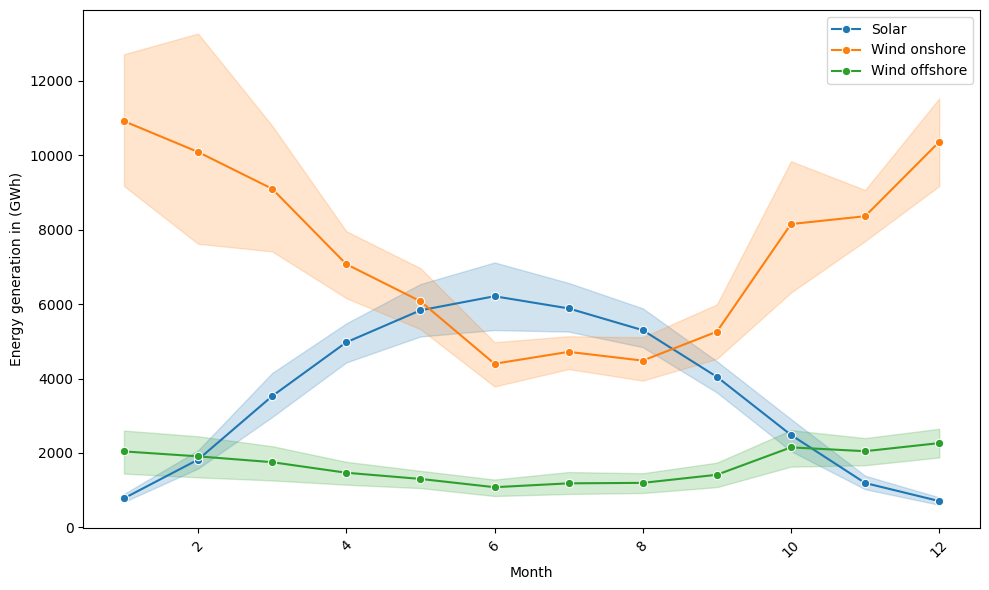

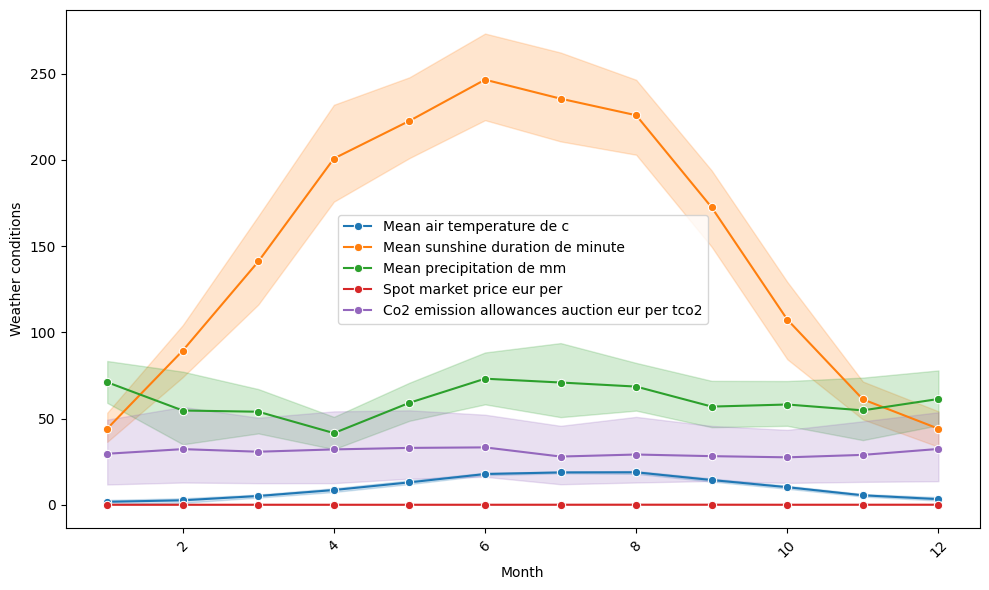

In [64]:
def average_lineplot(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

def simple_lineplot(df, y_values, x='Date', time=' '):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Weather conditions')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

average_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')   
#average_lineplot(df=data_df, y_values=['Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

simple_lineplot(df=data_df, y_values=['Mean_air_temperature_de_c',
        'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm',
        'Spot_market_price_eur_per_gwh',
        'Co2_emission_allowances_auction_eur_per_tco2'], x="Date", time='Month')   

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1678/2155932804.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df['Total_energy_generation_gwh'])


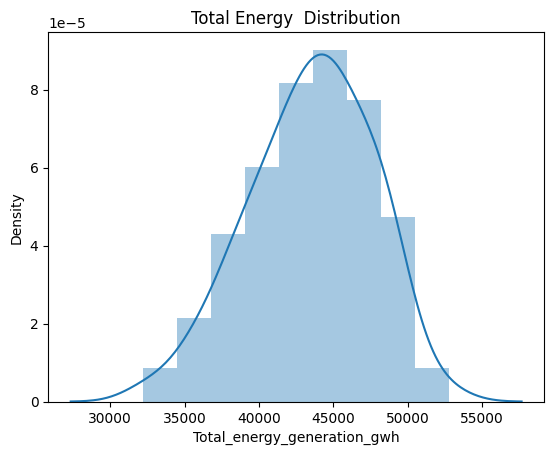

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1678/2155932804.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df['Solar_gwh'])


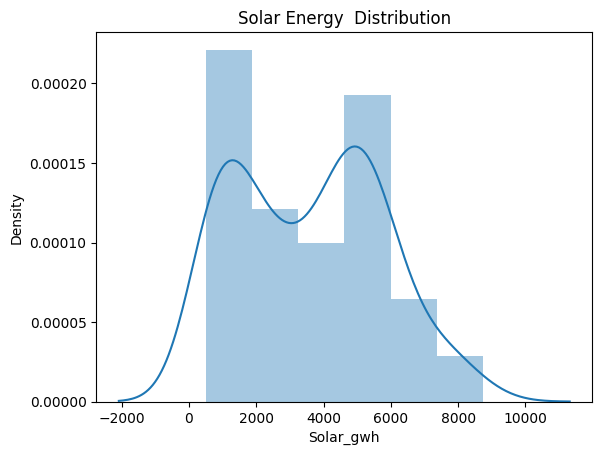

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1678/2155932804.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df['Wind_onshore_gwh'])


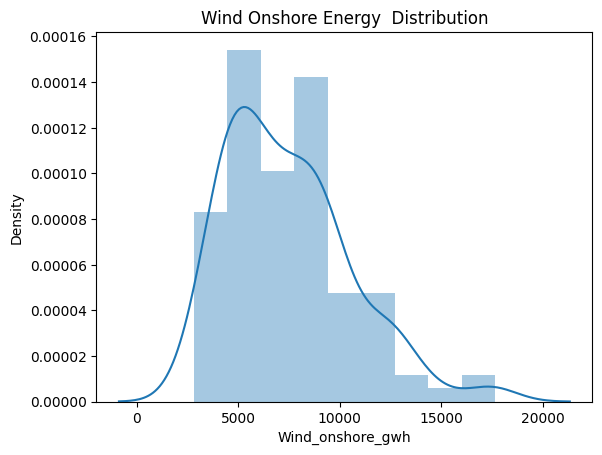

In [65]:
#'Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'
sns.distplot(data_df['Total_energy_generation_gwh'])
plt.title("Total Energy  Distribution")
plt.show()
sns.distplot(data_df['Solar_gwh'])
plt.title("Solar Energy  Distribution")
plt.show()
sns.distplot(data_df['Wind_onshore_gwh'])
plt.title("Wind Onshore Energy  Distribution")
plt.show()

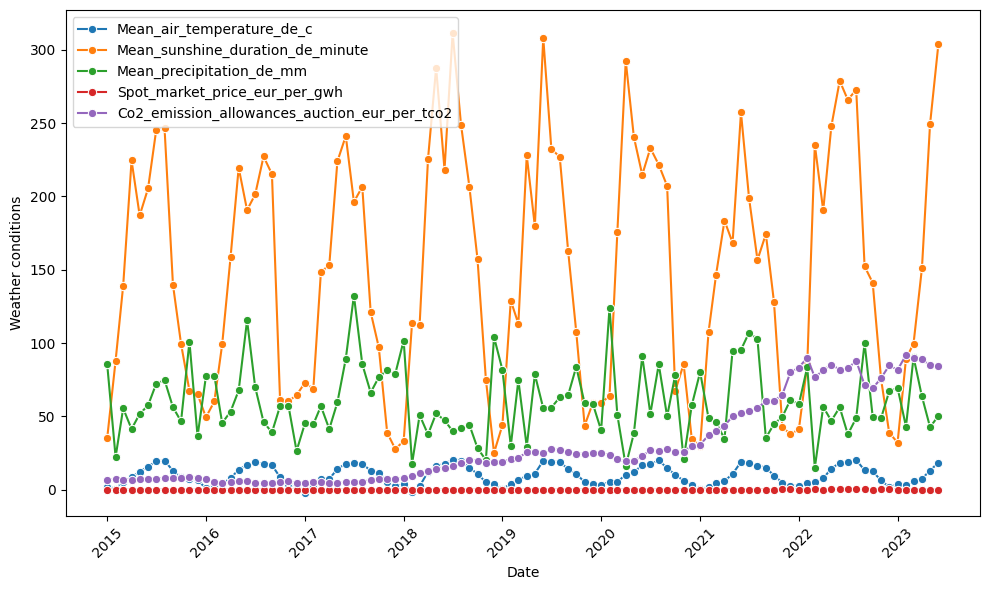

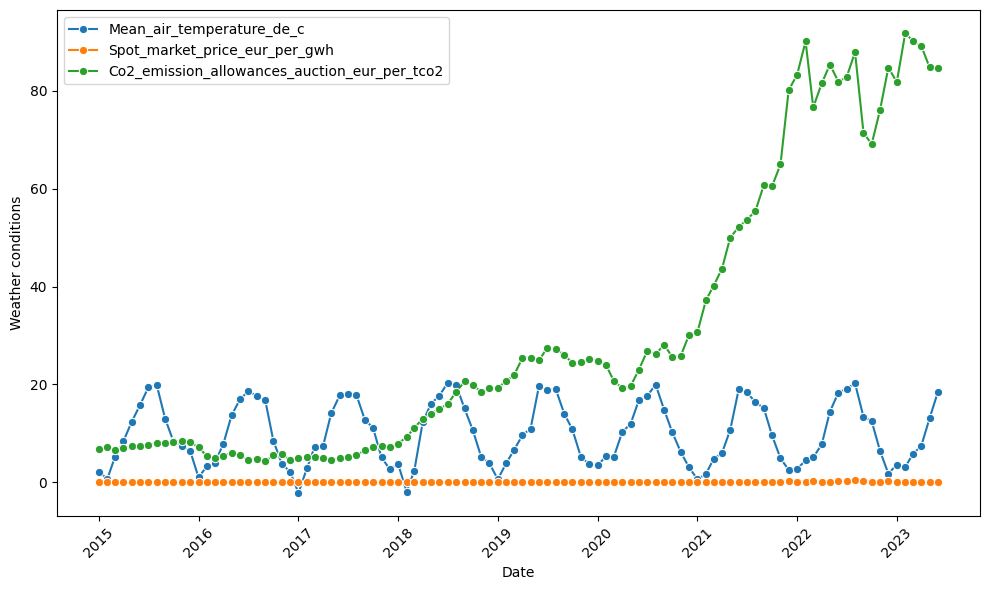

In [66]:
def plot_line_function(df, y_values, x='Date', time='Month'):
    # Convert the 'Date' column to pandas datetime with 'Year-Month' format
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')

    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        sns.lineplot(x=time, y=y, data=df, ax=ax, label=y, marker='o')

    ax.set(title='', ylabel='Weather conditions')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    plt.show()
columns_to_plot = ['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh', 'Co2_emission_allowances_auction_eur_per_tco2']
#columns_to_plot = ['Solar_gwh', 'Total_energy_generation_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh', 'Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh', 'Co2_emission_allowances_auction_eur_per_tco2']
plot_line_function(df=data_df, y_values=columns_to_plot, x="date", time='Date')

columns_to_plot1 = ['Mean_air_temperature_de_c', 'Spot_market_price_eur_per_gwh', 'Co2_emission_allowances_auction_eur_per_tco2']
plot_line_function(df=data_df, y_values=columns_to_plot1, x="date", time='Date')


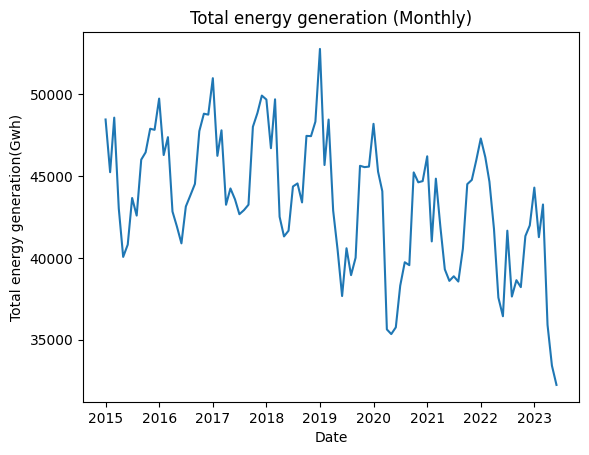

In [67]:
#['Dt_date', 'Solar_gwh', 'Total_energy_generation_gwh','Wind_offshore_gwh', 'Wind_onshore_gwh', 'Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute',
#       'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh','Co2_emission_allowances_auction_eur_per_tco2']
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y='Total_energy_generation_gwh', data=data_df, ax=ax)
ax.set(title='Total energy generation (Monthly)', ylabel='Total energy generation(Gwh)');

#### Univariate LSTM for energy generation

####  Univriate without resampling

data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 12) (102, 1) (100, 2, 1) (100, 1) 102
X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape = (80, 2, 1) (22, 2, 1) (80, 1) (22, 1)
data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 12) (102, 1) (100, 2, 1) (100, 1) 102
X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape = (80, 2, 1) (22, 2, 1) (80, 1) (22, 1)
Before model fitting
X_test_lstm =  (22, 2, 1)
y_test_lstm =  (22, 1)
X_train_lstm =  (80, 2, 1)
y_train_lstm =  (80, 1)
Epoch 1/100


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_88968/2961911873.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


3/3 [==============================] - 3s 110ms/step - loss: 0.1775 - val_loss: 0.3004
Epoch 2/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1706 - val_loss: 0.2916
Epoch 3/100
3/3 [==============================] - 0s 10ms/step - loss: 0.1643 - val_loss: 0.2822
Epoch 4/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1575 - val_loss: 0.2724
Epoch 5/100
3/3 [==============================] - 0s 12ms/step - loss: 0.1505 - val_loss: 0.2621
Epoch 6/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1430 - val_loss: 0.2513
Epoch 7/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1352 - val_loss: 0.2398
Epoch 8/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1272 - val_loss: 0.2275
Epoch 9/100
3/3 [==============================] - 0s 10ms/step - loss: 0.1187 - val_loss: 0.2143
Epoch 10/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1096 - val_loss: 0.2003
Epoch 11/100
3/3 [==================

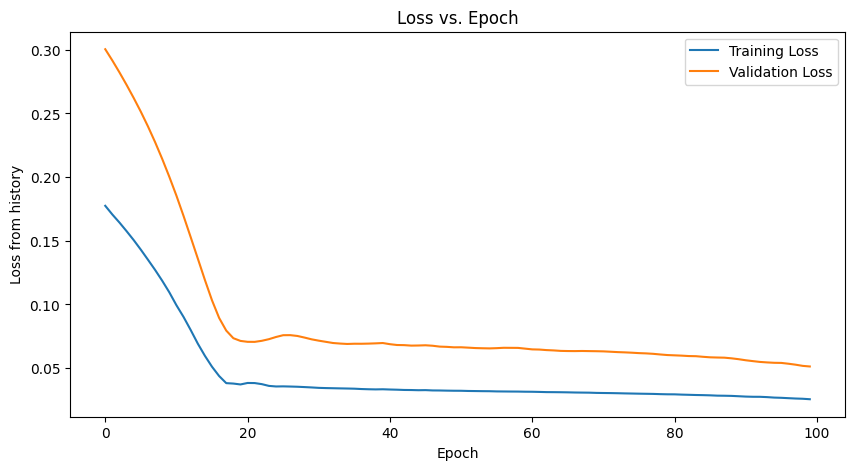

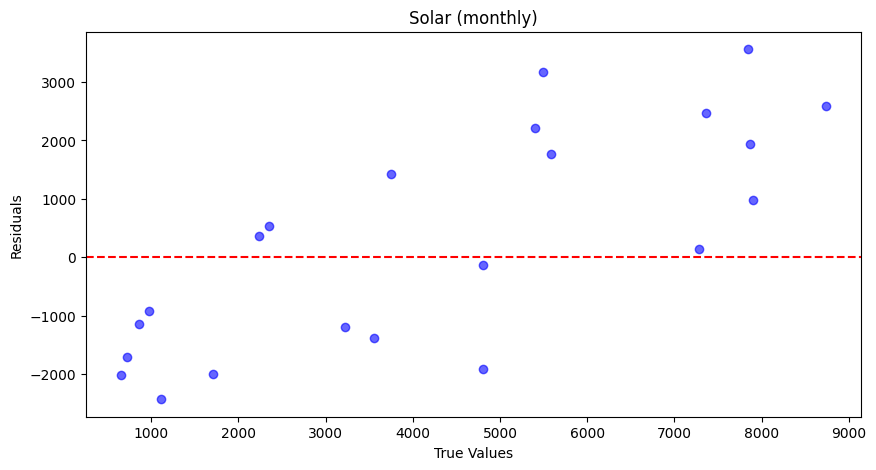

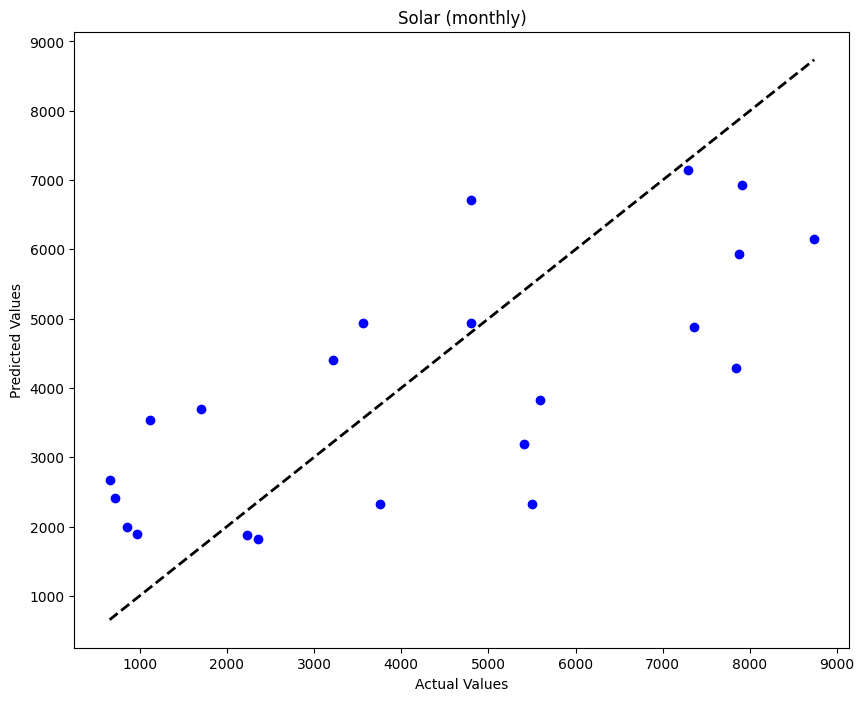

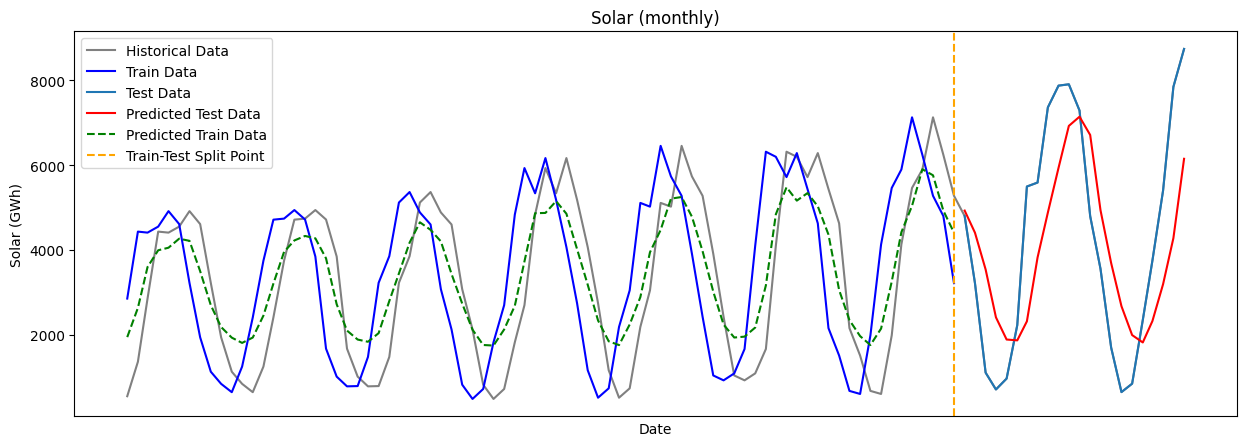

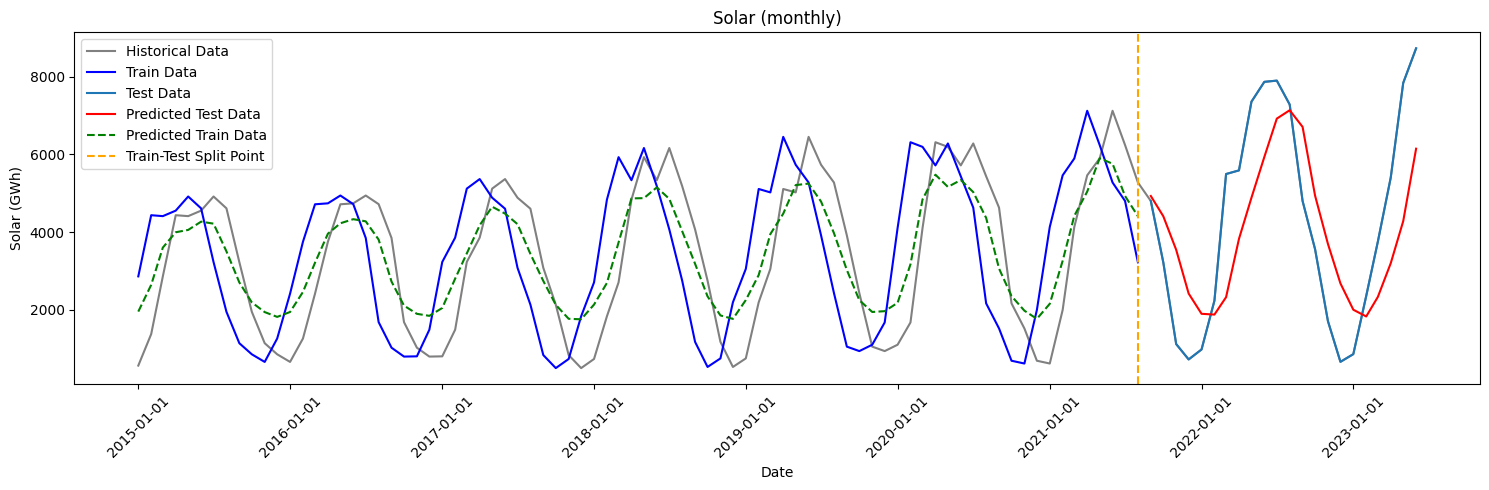

Model: "sequential_59"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_108 (LSTM)             (None, 2, 64)             16896     
                                                                 
 lstm_109 (LSTM)             (None, 32)                12416     
                                                                 
 dense_59 (Dense)            (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (80, 2, 1) (22, 2, 1) (80, 1) (22, 1) (100, 2, 1) (100, 1) (102, 1)


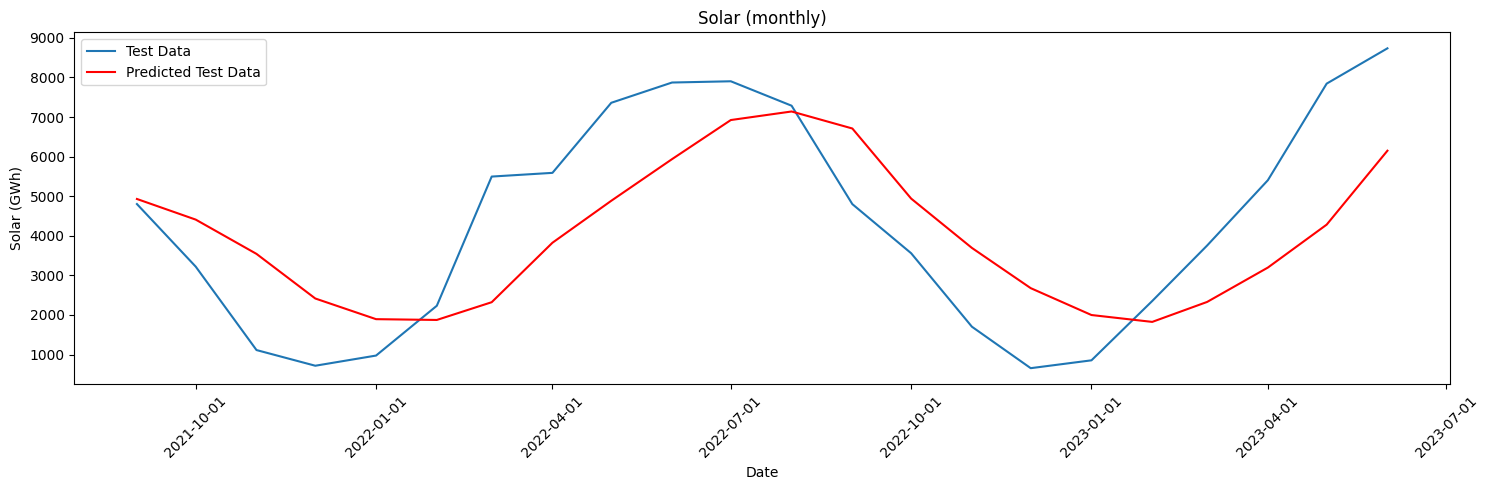

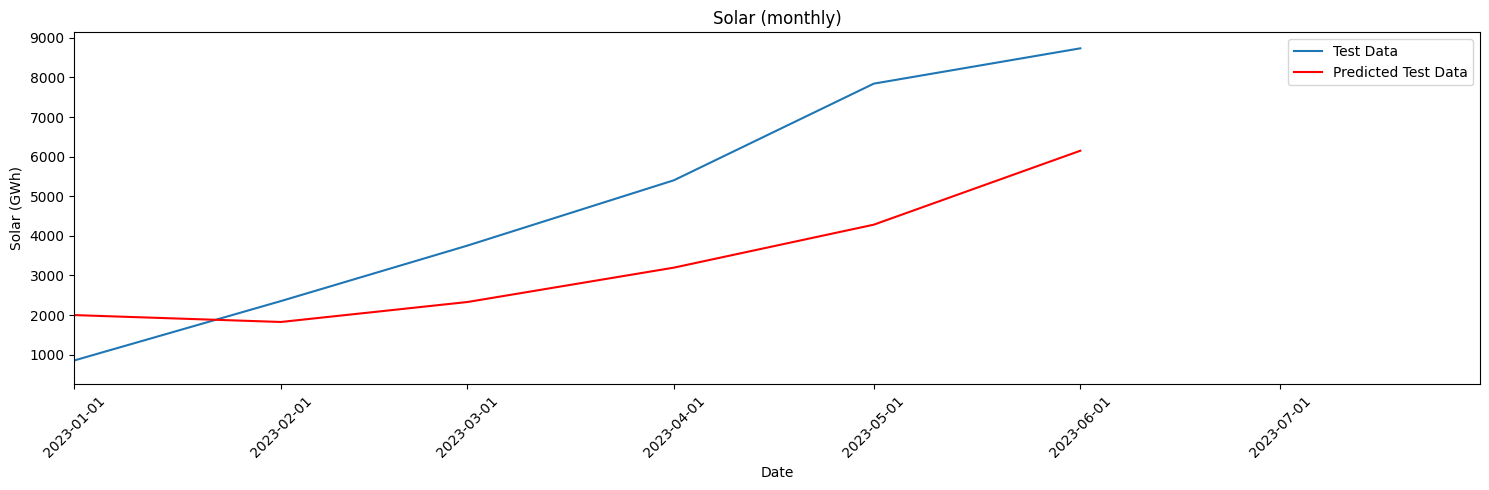

Model: "sequential_59"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_108 (LSTM)             (None, 2, 64)             16896     
                                                                 
 lstm_109 (LSTM)             (None, 32)                12416     
                                                                 
 dense_59 (Dense)            (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape = (80, 2, 1) (22, 2, 1) (80, 1) (22, 1) (100, 2, 1) (100, 1) (102, 1)


In [189]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback):
   
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    dfs = data_df[['Date', target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs[target].values.reshape(-1, 1))
   
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]


    print('data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]=',data_df.shape, data_scaled.shape, X_lstm.shape, y_lstm.shape, X_lstm.shape[0]+X_lstm.shape[1])
    print('X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape =',X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)
    
    print('data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]=',data_df.shape, data_scaled.shape, X_lstm.shape, y_lstm.shape, X_lstm.shape[0]+X_lstm.shape[1])
    print('X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape =',X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)
    
    print ('Before model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)

    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    print(model.summary())
   
    print ('After model fitting')
    print ('X_test_lstm = ',X_test_lstm.shape)
    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('X_train_lstm = ',X_train_lstm.shape)
    print ('y_train_lstm = ',y_train_lstm.shape)
     
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    print ('After prediction')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)

    print ('After inverse transformation on prediction data')
    print ('y_train_lstm = ',y_train_lstm.shape)
    print ('y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('X_train_lstm = ',y_train_lstm.shape)

    print ('y_test_lstm = ',y_test_lstm.shape)
    print ('y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('X_test_lstm = ',X_test_lstm.shape)
     
    

    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    #plt.axvline(x=train_size, color='gray', linestyle='--', label='Train-Test Split')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(dfs.index, dfs[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
   #plt.axvline(x=train_size, color='gray', linestyle='--', label='Train-Test Split')
    plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(model.summary()) 
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)

   
    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    #plt.axvline(x=train_index[-1], color='orange', linestyle='--', label='Train-Test Split Point')
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(15, 5))
    train_index = dfs.index[:train_size][-len(y_train_lstm):]
    test_index = dfs.index[train_size:]
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-07-31'))  # Set xlim to the specified range
    plt.legend()
    # Format date ticks on x-axis
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(model.summary()) 
    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, df_shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs.shape)

#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

lookback=2
results = lstm_model('Solar_gwh', data_df, lookback)   

##### Multivarite for monthly data 

In [68]:
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])  # Features
        y.append(data[i+lookback-1, -1])   # Target
    return np.array(X), np.array(y)

def lstm_mlvt_model(target, data_mlvt, features, lookback):
    dfs = data_mlvt[['Date'] + features + [target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)

    # Separate target and features
    target_data = dfs[[target]].values
    feature_data = dfs[features].values

    # Scale features and target separately
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    scaler_target = MinMaxScaler(feature_range=(0, 1))

    feature_scaled = scaler_features.fit_transform(feature_data)
    target_scaled = scaler_target.fit_transform(target_data)

    # Create sequences with scaled data
    data_scaled = np.hstack((feature_scaled, target_scaled))
    X_lstm, y_lstm = create_sequences(data_scaled, target_scaled, lookback)  # Pass target_scaled to create_sequences


    print('data_mlvt_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]=',data_mlvt.shape, data_scaled.shape, X_lstm.shape, y_lstm.shape, X_lstm.shape[0]+X_lstm.shape[1])
    print('X_lstm_shape, X_lstm_shape, y_lstm_shape, y_lstm_shape =',X_lstm.shape, X_lstm.shape, y_lstm.shape, y_lstm.shape)



    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_lstm, y_lstm, epochs=100, batch_size=30, validation_split=0.2, verbose=1)

    # LSTM prediction on test and train data
    y_pred_lstm = model.predict(X_lstm)

    # Reshape y_pred_lstm to 1-dimensional array
    y_pred_lstm = y_pred_lstm.reshape(-1)

    # Inverse transform the scaled data to get the original scale
    y_pred_lstm = scaler_target.inverse_transform(y_pred_lstm.reshape(-1, 1)).flatten()
    y_lstm = scaler_target.inverse_transform(y_lstm.reshape(-1, 1)).flatten()

    # Calculate residuals
    residuals = y_lstm - y_pred_lstm

    # Print shapes after inverse transform
    print("Shapes after inverse transform:")
    print("y_pred_lstm shape:", y_pred_lstm.shape)
    print("y_lstm shape:", y_lstm.shape)

    # Calculate metrics
    mse = mean_squared_error(y_lstm, y_pred_lstm)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_lstm, y_pred_lstm)
    r2 = r2_score(y_lstm, y_pred_lstm)

    # Print metrics
    print("Mean Squared Error (MSE):", mse)
    print("Root Mean Squared Error (RMSE):", rmse)
    print("Mean Absolute Error (MAE):", mae)
    print("R-squared (R^2) Score:", r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(target)

    plt.figure(figsize=(10, 8))
    plt.scatter(y_lstm, y_pred_lstm, label='Actual vs. Predicted', color='blue', alpha=0.7)
    plt.plot([y_lstm.min(), y_lstm.max()], [y_lstm.min(), y_lstm.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs. Predicted Values')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()



    # Plot actual vs. predicted values with time (including test data only)
    test_index = dfs.index[-len(y_lstm):]
    plt.figure(figsize=(10, 8))
    plt.plot(test_index, y_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_lstm, label='Predicted Test Data', color='red')
    plt.legend()
    plt.xticks([])
    plt.title(target)
    plt.ylabel(target)
    plt.xlabel('Date')
    plt.show()
    print(model.summary())
 #   # Plot actual vs. predicted values with time
 #   plt.figure(figsize=(10, 8))
 #   plt.scatter(dfs.index[-len(y_lstm):], y_lstm, label='True Values', color='blue')
 #   plt.scatter(dfs.index[-len(y_pred_lstm):], y_pred_lstm, label='Predicted Values', color='orange')
 #   plt.xlabel('Date')
 #   plt.ylabel(target)
 #   plt.title(target)
 #   plt.legend()
 #   plt.show()


In [70]:
columns_mlvt= ['Date','Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_mlvt].copy()
#data_mlvt.head()


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1678/737667555.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


data_mlvt_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 5) (102, 2) (90, 12, 1) (90,) 102
X_lstm_shape, X_lstm_shape, y_lstm_shape, y_lstm_shape = (90, 12, 1) (90, 12, 1) (90,) (90,)
Epoch 1/100
3/3 [==============================] - 1s 143ms/step - loss: 0.1729 - val_loss: 0.2740
Epoch 2/100
3/3 [==============================] - 0s 14ms/step - loss: 0.1517 - val_loss: 0.2468
Epoch 3/100
3/3 [==============================] - 0s 13ms/step - loss: 0.1319 - val_loss: 0.2188
Epoch 4/100
3/3 [==============================] - 0s 15ms/step - loss: 0.1121 - val_loss: 0.1888
Epoch 5/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0924 - val_loss: 0.1576
Epoch 6/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0750 - val_loss: 0.1307
Epoch 7/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0655 - val_loss: 0.1183
Epoch 8/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0668 - va

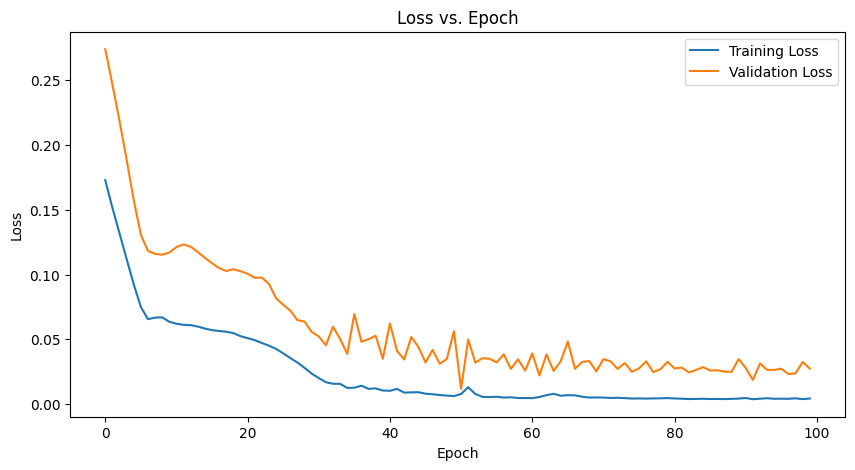

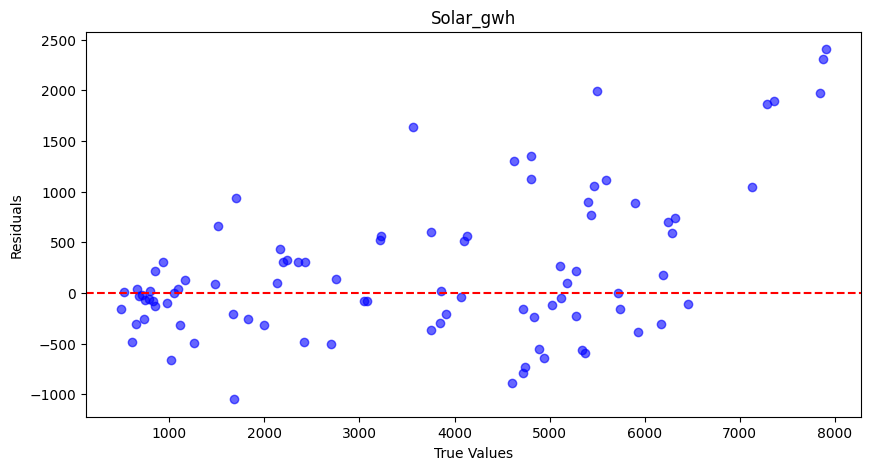

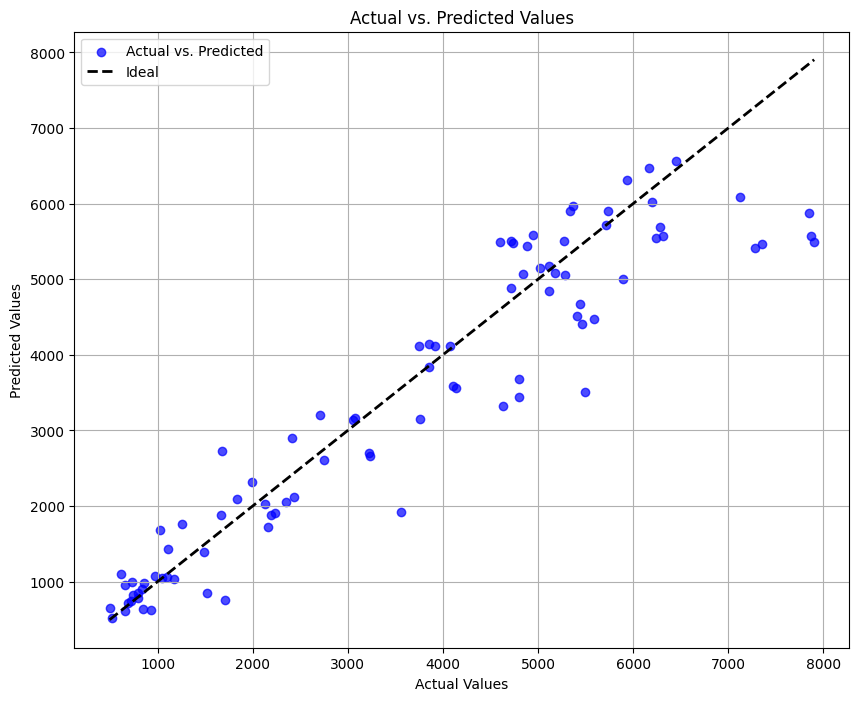

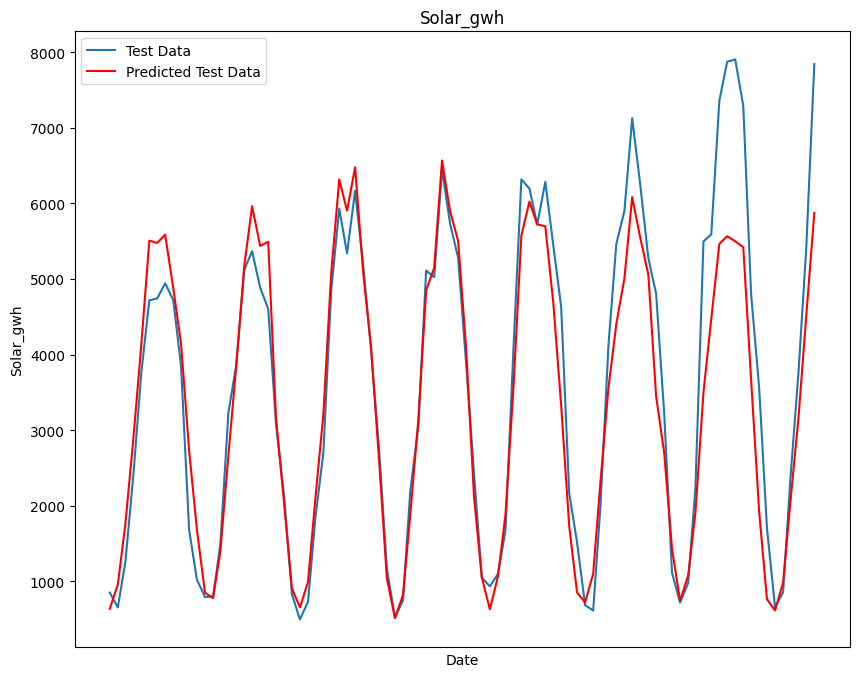

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 12, 64)            16896     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [71]:

#data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_sunshine_duration_de_minute']
target = 'Solar_gwh'
lookback = 12
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
lstm_mlvt_model(target, data_mlvt, features, lookback)

data_mlvt_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 5) (102, 3) (90, 12, 2) (90,) 102
X_lstm_shape, X_lstm_shape, y_lstm_shape, y_lstm_shape = (90, 12, 2) (90, 12, 2) (90,) (90,)
Epoch 1/100


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_1678/737667555.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


3/3 [==============================] - 1s 118ms/step - loss: 0.1552 - val_loss: 0.2481
Epoch 2/100
3/3 [==============================] - 0s 14ms/step - loss: 0.1330 - val_loss: 0.2153
Epoch 3/100
3/3 [==============================] - 0s 14ms/step - loss: 0.1087 - val_loss: 0.1802
Epoch 4/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0881 - val_loss: 0.1470
Epoch 5/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0713 - val_loss: 0.1236
Epoch 6/100
3/3 [==============================] - 0s 12ms/step - loss: 0.0655 - val_loss: 0.1176
Epoch 7/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0737 - val_loss: 0.1158
Epoch 8/100
3/3 [==============================] - 0s 13ms/step - loss: 0.0703 - val_loss: 0.1152
Epoch 9/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0650 - val_loss: 0.1210
Epoch 10/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0629 - val_loss: 0.1266
Epoch 11/100
3/3 [============

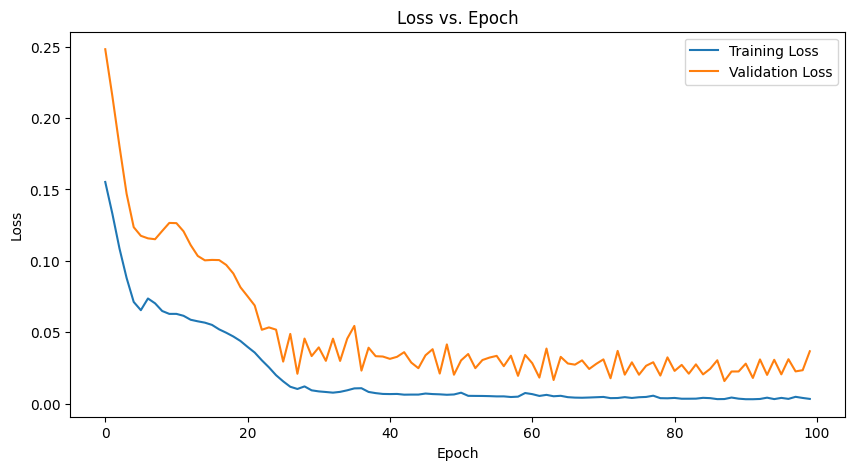

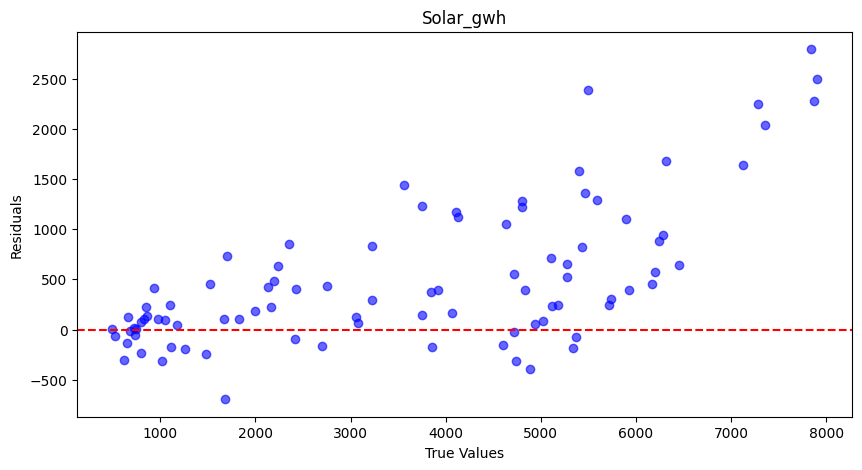

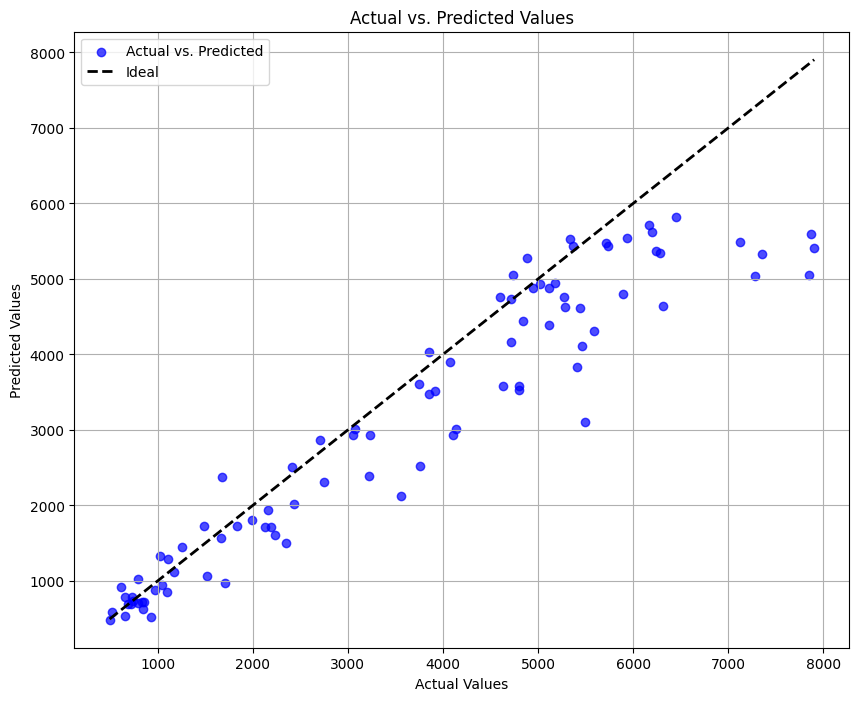

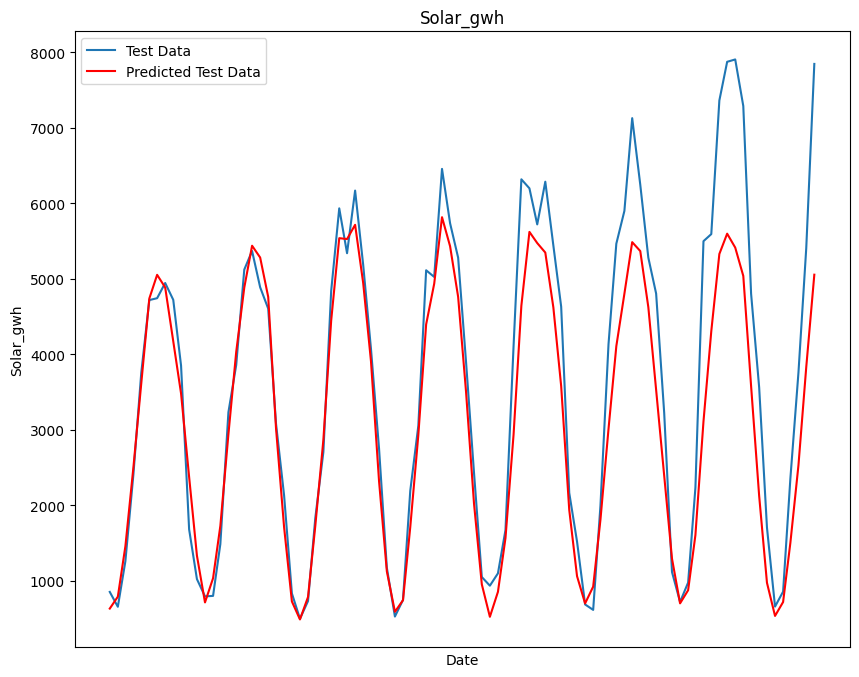

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 12, 64)            17152     
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29601 (115.63 KB)
Trainable params: 29601 (115.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [72]:

#data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c']
target = 'Solar_gwh'
lookback = 12
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
lstm_mlvt_model(target, data_mlvt, features, lookback)

data_mlvt_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 5) (102, 4) (90, 12, 3) (90,) 102
X_lstm_shape, X_lstm_shape, y_lstm_shape, y_lstm_shape = (90, 12, 3) (90, 12, 3) (90,) (90,)
Epoch 1/100
3/3 [==============================] - 1s 93ms/step - loss: 0.1797 - val_loss: 0.2798
Epoch 2/100
3/3 [==============================] - 0s 14ms/step - loss: 0.1528 - val_loss: 0.2454
Epoch 3/100
3/3 [==============================] - 0s 12ms/step - loss: 0.1268 - val_loss: 0.2094
Epoch 4/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1018 - val_loss: 0.1741
Epoch 5/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0811 - val_loss: 0.1394
Epoch 6/100
3/3 [==============================] - 0s 12ms/step - loss: 0.0659 - val_loss: 0.1167
Epoch 7/100
3/3 [==============================] - 0s 13ms/step - loss: 0.0658 - val_loss: 0.1125
Epoch 8/100
3/3 [==============================] - 0s 12ms/step - loss: 0.0702 - val

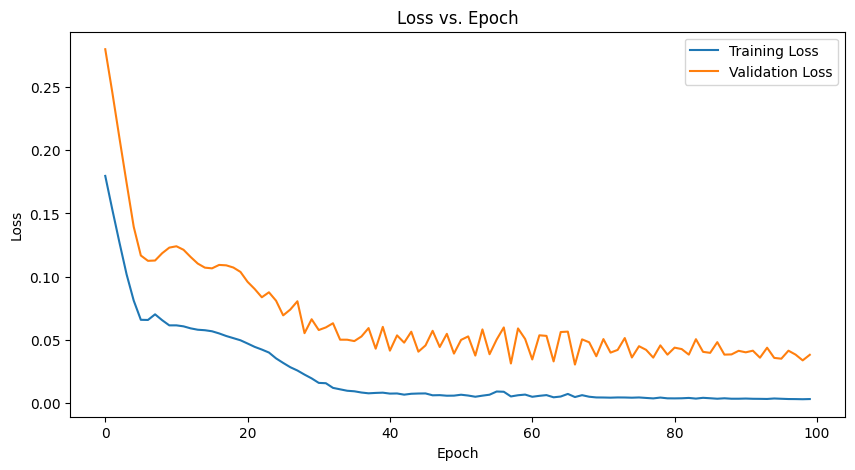

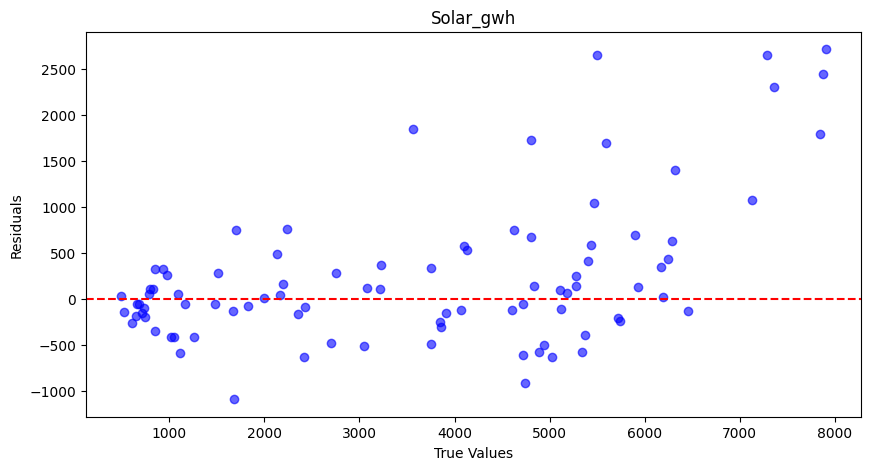

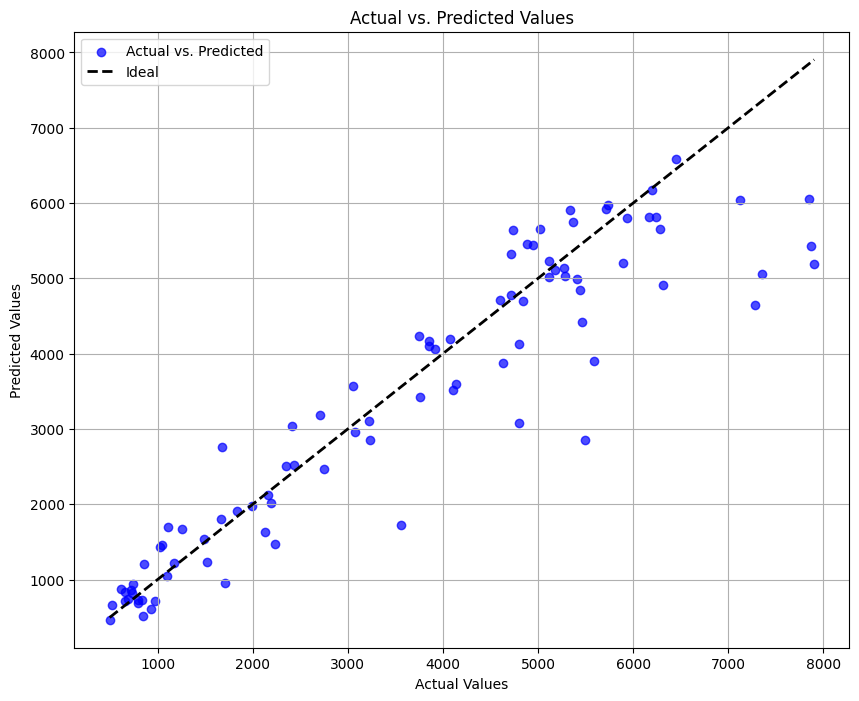

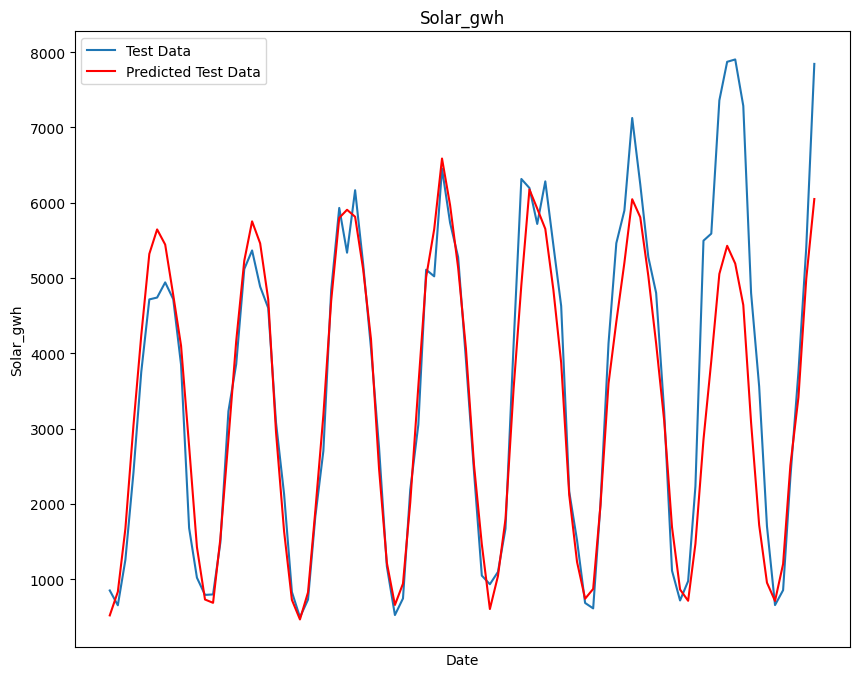

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 12, 64)            17408     
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29857 (116.63 KB)
Trainable params: 29857 (116.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [73]:

#data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
lstm_mlvt_model(target, data_mlvt, features, lookback)

In [56]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

def lstm_model(target, data_df, lookback, sampling_frequency='M'):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        dfs = data_df[['Date', target]]
        dfs['Date'] = pd.to_datetime(dfs['Date'])
        dfs.set_index('Date', inplace=True)
        dfs_resampled = dfs.resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled[target].values.reshape(-1, 1))
    #data_scaled = scaler.fit_transform(dfs_resampled[target].values)

    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    split_index = int(len(data_scaled) * 0.8)

    print('train_size, split_index=',train_size, split_index )
    
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size-lookback:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size-lookback:]


    print('data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]=',data_df.shape, data_scaled.shape, X_lstm.shape, y_lstm.shape, X_lstm.shape[0]+X_lstm.shape[1])
    print('X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape =',X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape)

    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    #model.add(LSTM(units=256, activation='relu', input_shape=(lookback, 1), return_sequences=True))
    #model.add(LSTM(units=128, activation='relu'))
    #model.add(Dense(1, activation='linear'))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    print(model.summary())
  

    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    print ('1y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('1X_test_lstm = ',X_test_lstm.shape)
    print ('1y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('1y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('1y_test_lstm = ',y_test_lstm.shape)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm)
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm)
    y_train_lstm = scaler.inverse_transform(y_train_lstm)
    y_test_lstm = scaler.inverse_transform(y_test_lstm)

    print ('2y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('2X_test_lstm = ',X_test_lstm.shape)
    print ('2y_pred_train_lstm = ',y_pred_train_lstm.shape)
    print ('2y_pred_test_lstm = ',y_pred_test_lstm.shape)
    print ('2y_test_lstm = ',y_test_lstm.shape)
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)
    
    # Calculate residuals
    residuals = y_test_lstm - y_pred_test_lstm
    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
    #plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x= train_size, color='gray', linestyle='--', label='Train-Test Split')
    plt.legend()
    plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

      
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[train_size:]
 #  plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
 #  plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
 #  plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.xticks([])
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    print(model.summary())

    print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
    }


train_size, split_index= 80 81
data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 12) (102, 1) (100, 2, 1) (100, 1) 102
X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape = (80, 2, 1) (22, 2, 1) (80, 1) (22, 1)
Epoch 1/100
3/3 [==============================] - 1s 83ms/step - loss: 0.1816 - val_loss: 0.3088
Epoch 2/100
3/3 [==============================] - 0s 8ms/step - loss: 0.1766 - val_loss: 0.3021
Epoch 3/100
3/3 [==============================] - 0s 8ms/step - loss: 0.1714 - val_loss: 0.2946
Epoch 4/100
3/3 [==============================] - 0s 8ms/step - loss: 0.1655 - val_loss: 0.2856
Epoch 5/100
3/3 [==============================] - 0s 8ms/step - loss: 0.1586 - val_loss: 0.2758
Epoch 6/100
3/3 [==============================] - 0s 9ms/step - loss: 0.1513 - val_loss: 0.2655
Epoch 7/100
3/3 [==============================] - 0s 8ms/step - loss: 0.1439 - val_loss: 0.2548
Epoch 8/100
3/3 [================

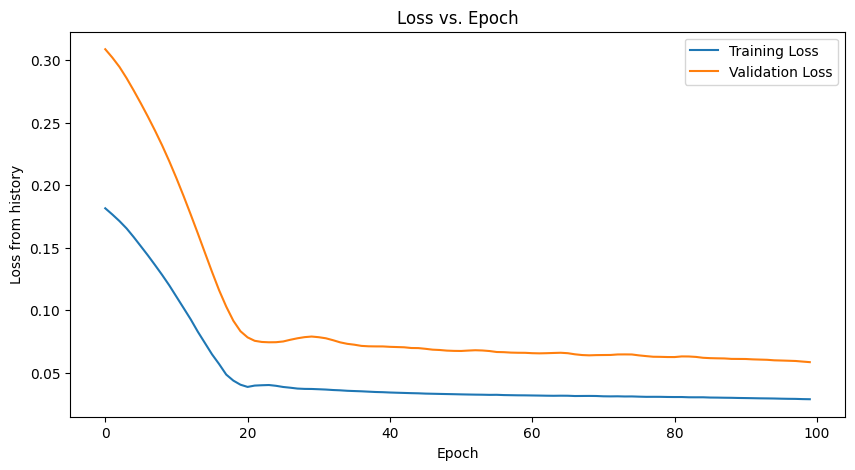

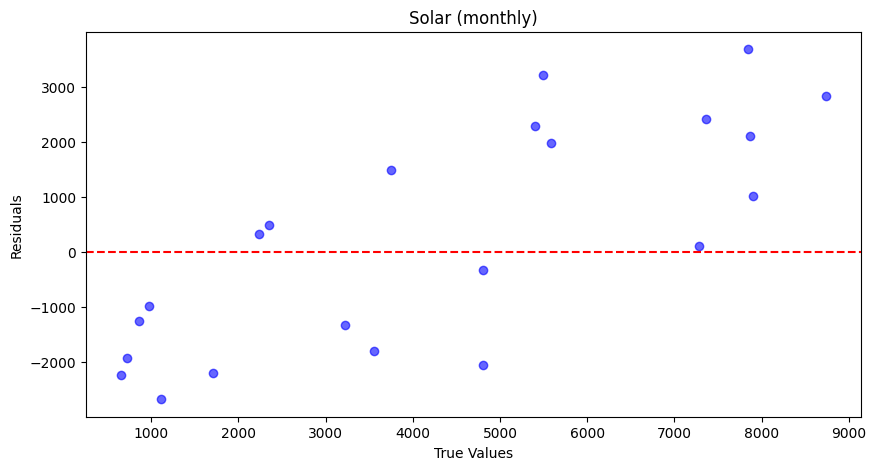

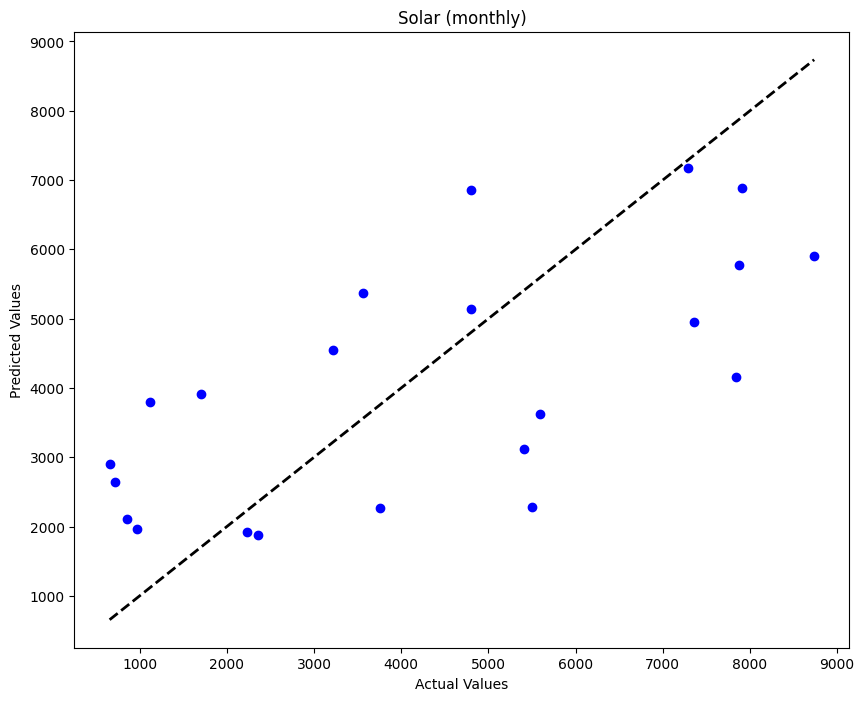

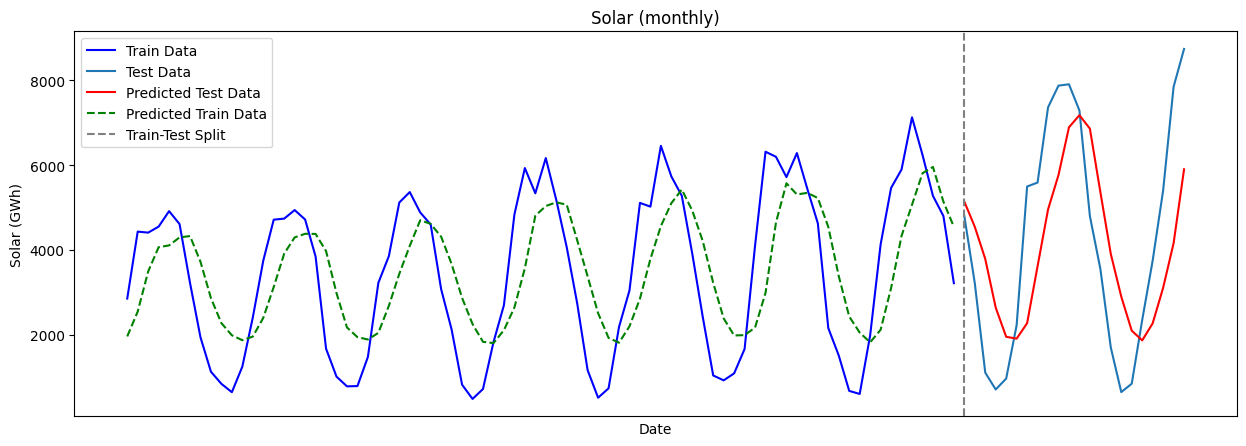

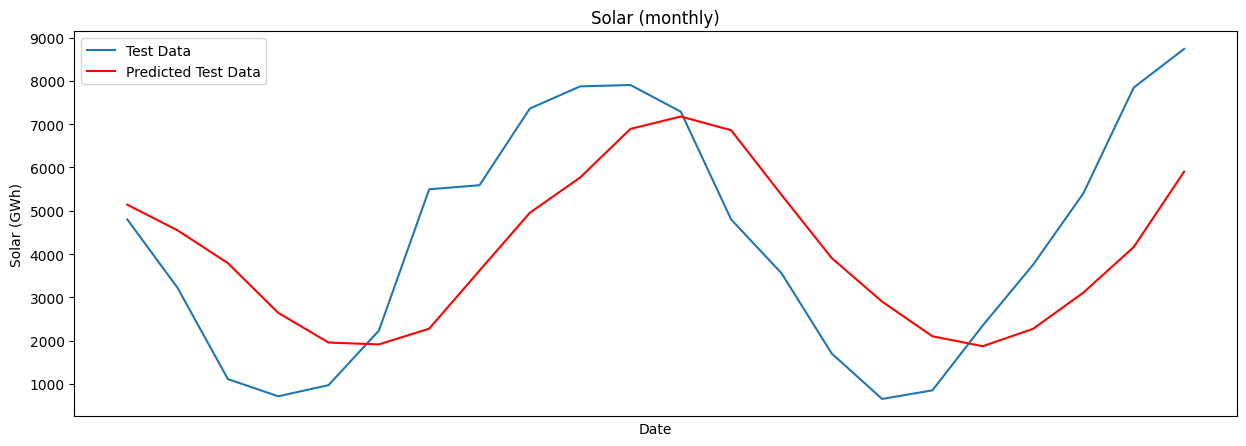

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_20 (LSTM)              (None, 2, 64)             16896     
                                                                 
 lstm_21 (LSTM)              (None, 32)                12416     
                                                                 
 dense_10 (Dense)            (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (80, 2, 1) (22, 2, 1) (80, 1) (22, 1) (100, 2, 1) (100, 1) (102, 12)


In [57]:
 lookback=2
results = lstm_model('Solar_gwh', data_df, lookback, sampling_frequency=None)

train_size, split_index= 69 81
data_df_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 12) (102, 1) (87, 15, 1) (87, 1) 102
X_train_lstm_shape, X_test_lstm_shape, y_train_lstm_shape, y_test_lstm_shape = (69, 15, 1) (33, 15, 1) (69, 1) (33, 1)
Epoch 1/100
3/3 [==============================] - 1s 115ms/step - loss: 0.3238 - val_loss: 0.1454
Epoch 2/100
3/3 [==============================] - 0s 42ms/step - loss: 0.1926 - val_loss: 0.0566
Epoch 3/100
3/3 [==============================] - 0s 33ms/step - loss: 0.0440 - val_loss: 0.1182
Epoch 4/100
3/3 [==============================] - 0s 31ms/step - loss: 0.1300 - val_loss: 0.0319
Epoch 5/100
3/3 [==============================] - 0s 33ms/step - loss: 0.0278 - val_loss: 0.0411
Epoch 6/100
3/3 [==============================] - 0s 34ms/step - loss: 0.0540 - val_loss: 0.0486
Epoch 7/100
3/3 [==============================] - 0s 32ms/step - loss: 0.0640 - val_loss: 0.0443
Epoch 8/100
3/3 [========

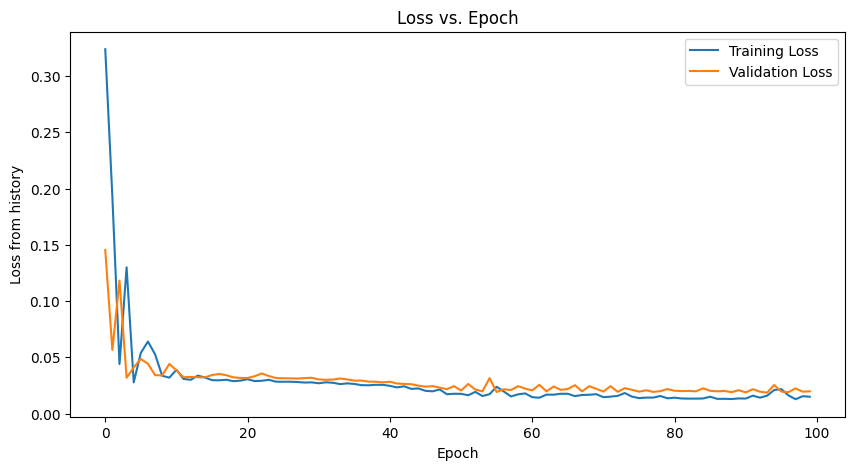

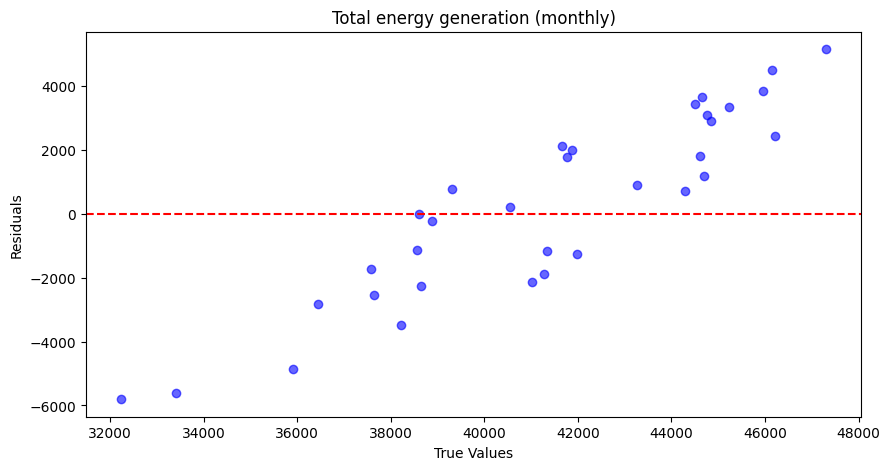

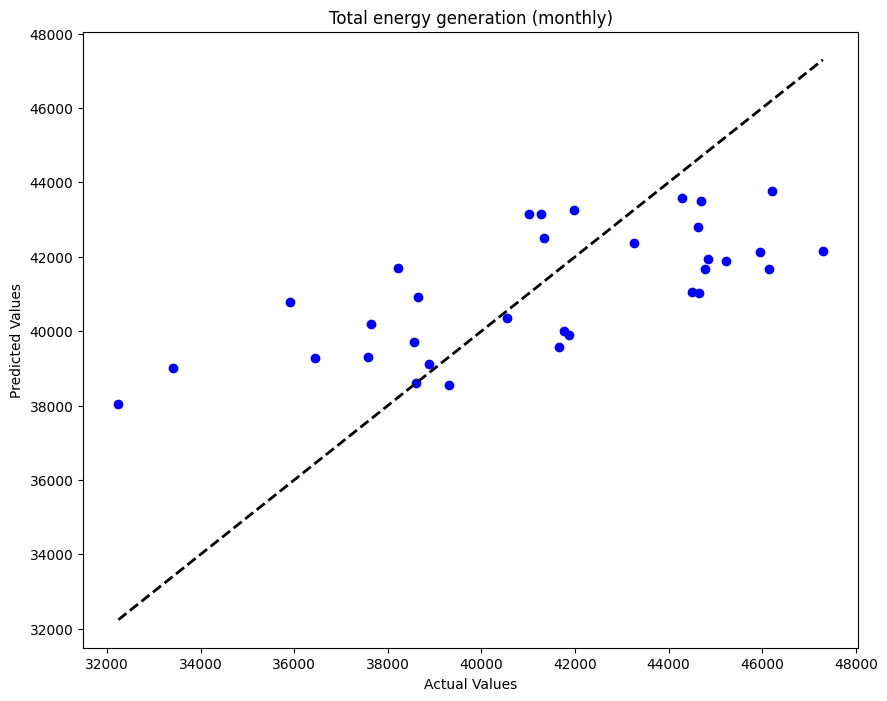

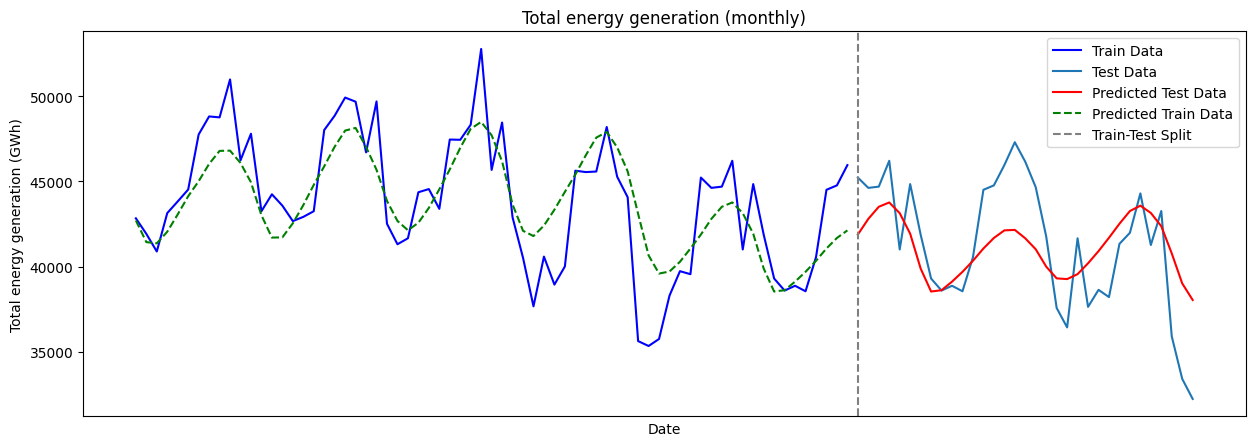

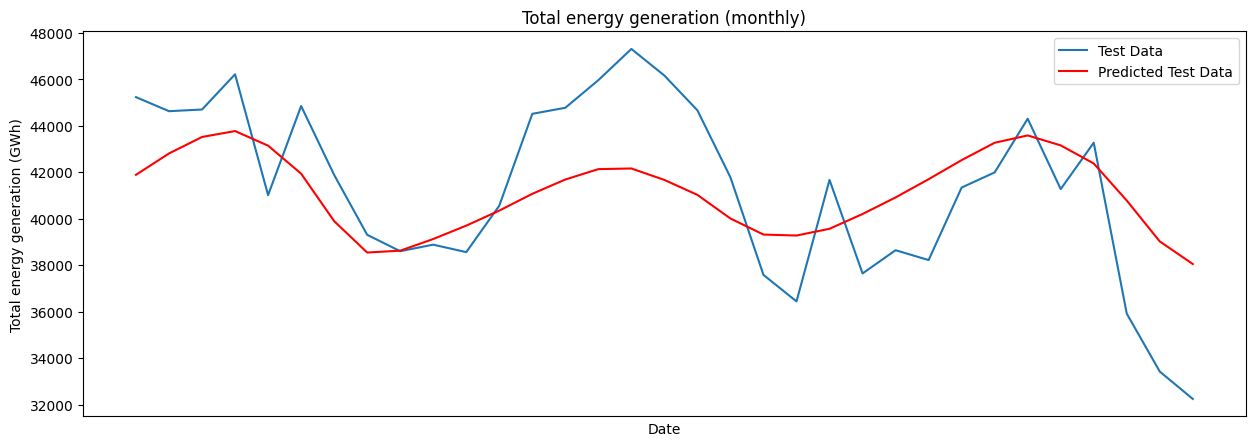

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_14 (LSTM)              (None, 15, 256)           264192    
                                                                 
 lstm_15 (LSTM)              (None, 128)               197120    
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 461441 (1.76 MB)
Trainable params: 461441 (1.76 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape = (69, 15, 1) (33, 15, 1) (69, 1) (33, 1) (87, 15, 1) (87, 1) (102, 12)


In [49]:
#['Dt_date', 'Solar_gwh', 'Total_energy_generation_gwh','Wind_offshore_gwh', 'Wind_onshore_gwh', 'Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute',
#       'Mean_precipitation_de_mm', 'Spot_market_price_eur_per_gwh','Co2_emission_allowances_auction_eur_per_tco2']
lookback=15
results = lstm_model('Total_energy_generation_gwh', data_df, lookback, sampling_frequency=None)

##  Multivariate LSTM

In [128]:
def create_sequences(data, target_idx, features_idx, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X_row = []
        for idx in features_idx:
            X_row.append(data[i:i+lookback, idx].reshape(-1, 1))
        X.append(np.concatenate(X_row, axis=1))
        y.append(data[i+lookback, target_idx])
    return np.array(X), np.array(y)

def lstm_mlvt_model(target, data_df, features, lookback):
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')

    target_idx = data_df.columns.get_loc(target)
    features_idx = [data_df.columns.get_loc(feature) for feature in features]

    data_scaled = data_df[features + [target]].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data_scaled)

    X_lstm, y_lstm = create_sequences(data_scaled, target_idx, features_idx, lookback)

    train_size = int(len(X_lstm) * 0.8)

    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features))))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    print(model.summary())

    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)

    y_pred_train_lstm = scaler.inverse_transform(y_pred_train_lstm).ravel()
    y_pred_test_lstm = scaler.inverse_transform(y_pred_test_lstm).ravel()
    y_train_lstm = scaler.inverse_transform(y_train_lstm).ravel()
    y_test_lstm = scaler.inverse_transform(y_test_lstm).ravel()

    train_rmse = np.sqrt(mean_squared_error(y_train_lstm, y_pred_train_lstm))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_test_lstm))
    train_mse = mean_squared_error(y_train_lstm, y_pred_train_lstm)
    test_mse = mean_squared_error(y_test_lstm, y_pred_test_lstm)
    train_mae = mean_absolute_error(y_train_lstm, y_pred_train_lstm)
    test_mae = mean_absolute_error(y_test_lstm, y_pred_test_lstm)
    train_r2 = r2_score(y_train_lstm, y_pred_train_lstm)
    test_r2 = r2_score(y_test_lstm, y_pred_test_lstm)

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    residuals = y_test_lstm - y_pred_test_lstm

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm, y_pred_test_lstm, label='', color='blue')
    plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    plt.figure(figsize=(15, 5))
    train_index = data_df.index[:train_size][-len(y_train_lstm):]
    test_index = data_df.index[train_size:]
    plt.plot(data_df.index, data_df[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.axvline(x=train_size, color='gray', linestyle='--', label='Train-Test Split')
    plt.legend()
    plt.xticks(rotation=45)
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

# Usage example:
# lstm_mlvt_model('Solar_gwh', data_mlvt, ['Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm'], 12)


In [129]:
columns_mlvt= ['Date','Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
data_mlvt = data_df[columns_mlvt].copy()
#data_mlvt.head()

features = ['Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
lstm_mlvt_model(target, data_mlvt, features, lookback)

IndexError: index 4 is out of bounds for axis 1 with size 4

In [1145]:
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])  # Features
        y.append(data[i+lookback-1, -1])   # Target
    return np.array(X), np.array(y)

def lstm_mlvt_model(target, data_mlvt, features, lookback):
    dfs = data_mlvt[['Date'] + features + [target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)

    # Separate target and features
    target_data = dfs[[target]].values
    feature_data = dfs[features].values

    # Scale features and target separately
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    scaler_target = MinMaxScaler(feature_range=(0, 1))

    feature_scaled = scaler_features.fit_transform(feature_data)
    target_scaled = scaler_target.fit_transform(target_data)

    # Create sequences with scaled data
    data_scaled = np.hstack((feature_scaled, target_scaled))
    X_lstm, y_lstm = create_sequences(data_scaled, target_scaled, lookback)  # Pass target_scaled to create_sequences


    print('data_mlvt_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]=',data_mlvt.shape, data_scaled.shape, X_lstm.shape, y_lstm.shape, X_lstm.shape[0]+X_lstm.shape[1])
    print('X_lstm_shape, X_lstm_shape, y_lstm_shape, y_lstm_shape =',X_lstm.shape, X_lstm.shape, y_lstm.shape, y_lstm.shape)



    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_lstm, y_lstm, epochs=100, batch_size=30, validation_split=0.2, verbose=1)

    # LSTM prediction on test and train data
    y_pred_lstm = model.predict(X_lstm)

    # Reshape y_pred_lstm to 1-dimensional array
    y_pred_lstm = y_pred_lstm.reshape(-1)

    # Inverse transform the scaled data to get the original scale
    y_pred_lstm = scaler_target.inverse_transform(y_pred_lstm.reshape(-1, 1)).flatten()
    y_lstm = scaler_target.inverse_transform(y_lstm.reshape(-1, 1)).flatten()

    # Calculate residuals
    residuals = y_lstm - y_pred_lstm

    # Print shapes after inverse transform
    print("Shapes after inverse transform:")
    print("y_pred_lstm shape:", y_pred_lstm.shape)
    print("y_lstm shape:", y_lstm.shape)

    # Calculate metrics
    mse = mean_squared_error(y_lstm, y_pred_lstm)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_lstm, y_pred_lstm)
    r2 = r2_score(y_lstm, y_pred_lstm)

    # Print metrics
    print("Mean Squared Error (MSE):", mse)
    print("Root Mean Squared Error (RMSE):", rmse)
    print("Mean Absolute Error (MAE):", mae)
    print("R-squared (R^2) Score:", r2)

    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_lstm, residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(target)

    plt.figure(figsize=(10, 8))
    plt.scatter(y_lstm, y_pred_lstm, label='Actual vs. Predicted', color='blue', alpha=0.7)
    plt.plot([y_lstm.min(), y_lstm.max()], [y_lstm.min(), y_lstm.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs. Predicted Values')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()



    # Plot actual vs. predicted values with time (including test data only)
    test_index = dfs.index[-len(y_lstm):]
    plt.figure(figsize=(10, 8))
    plt.plot(test_index, y_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_lstm, label='Predicted Test Data', color='red')
    plt.legend()
    plt.xticks([])
    plt.title(target)
    plt.ylabel(target)
    plt.xlabel('Date')
    plt.show()
    print(model.summary())
 #   # Plot actual vs. predicted values with time
 #   plt.figure(figsize=(10, 8))
 #   plt.scatter(dfs.index[-len(y_lstm):], y_lstm, label='True Values', color='blue')
 #   plt.scatter(dfs.index[-len(y_pred_lstm):], y_pred_lstm, label='Predicted Values', color='orange')
 #   plt.xlabel('Date')
 #   plt.ylabel(target)
 #   plt.title(target)
 #   plt.legend()
 #   plt.show()


In [1146]:
columns_mlvt= ['Date','Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_mlvt].copy()
#data_mlvt.head()


In [964]:
#print(data_mlvt.isnull().sum())
data_mlvt.shape, 72+30

((102, 5), 102)

data_mlvt_shape, data_scaled_shape, X_lstm_shape, y_lstm_shape, X_lstm_shape[0]+X_lstm_shape[1]= (102, 5) (102, 4) (90, 12, 3) (90,) 102
X_lstm_shape, X_lstm_shape, y_lstm_shape, y_lstm_shape = (90, 12, 3) (90, 12, 3) (90,) (90,)
Epoch 1/100
3/3 [==============================] - 2s 115ms/step - loss: 0.1609 - val_loss: 0.2552
Epoch 2/100
3/3 [==============================] - 0s 15ms/step - loss: 0.1370 - val_loss: 0.2212
Epoch 3/100
3/3 [==============================] - 0s 14ms/step - loss: 0.1126 - val_loss: 0.1836
Epoch 4/100
3/3 [==============================] - 0s 17ms/step - loss: 0.0859 - val_loss: 0.1447
Epoch 5/100
3/3 [==============================] - 0s 15ms/step - loss: 0.0714 - val_loss: 0.1191
Epoch 6/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0633 - val_loss: 0.1141
Epoch 7/100
3/3 [==============================] - 0s 13ms/step - loss: 0.0665 - val_loss: 0.1127
Epoch 8/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0661 - va

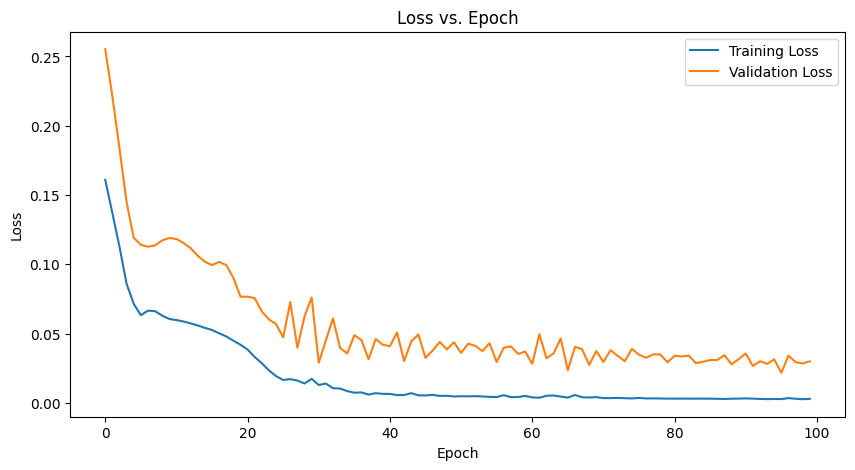

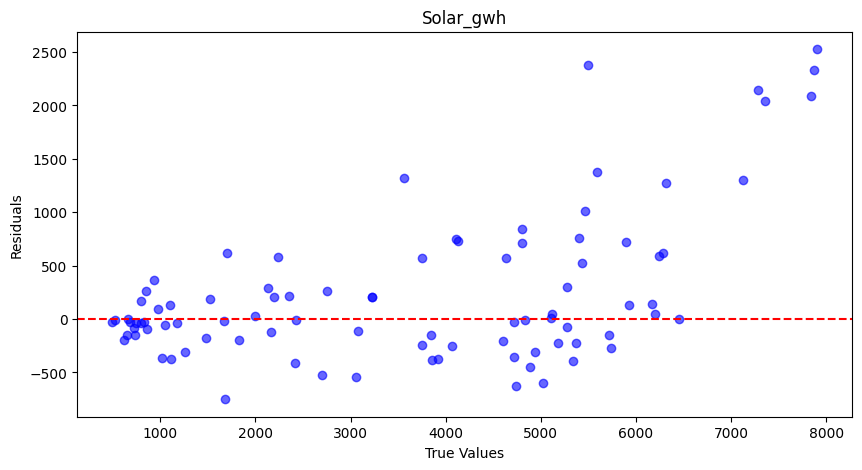

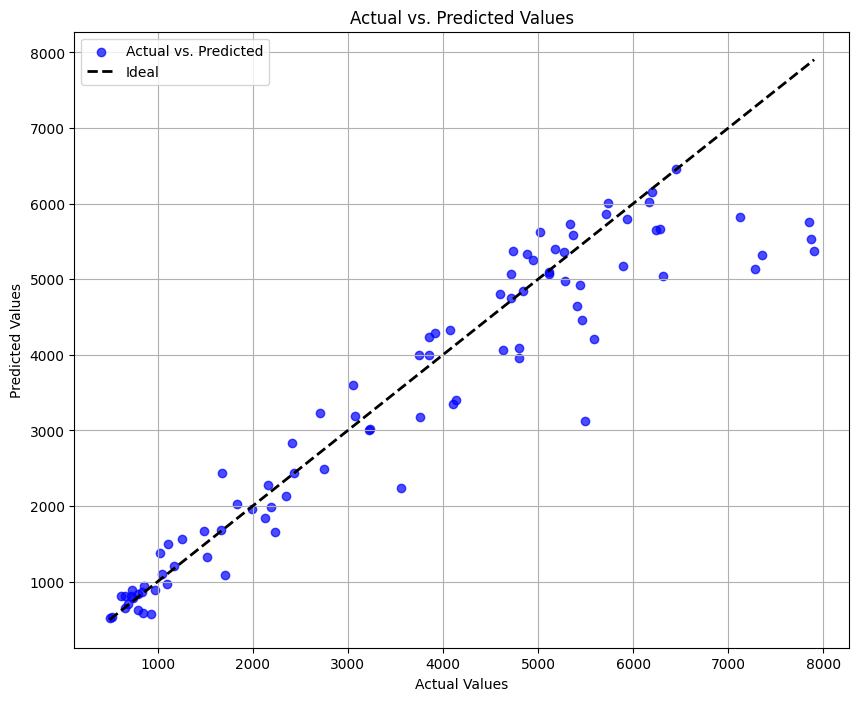

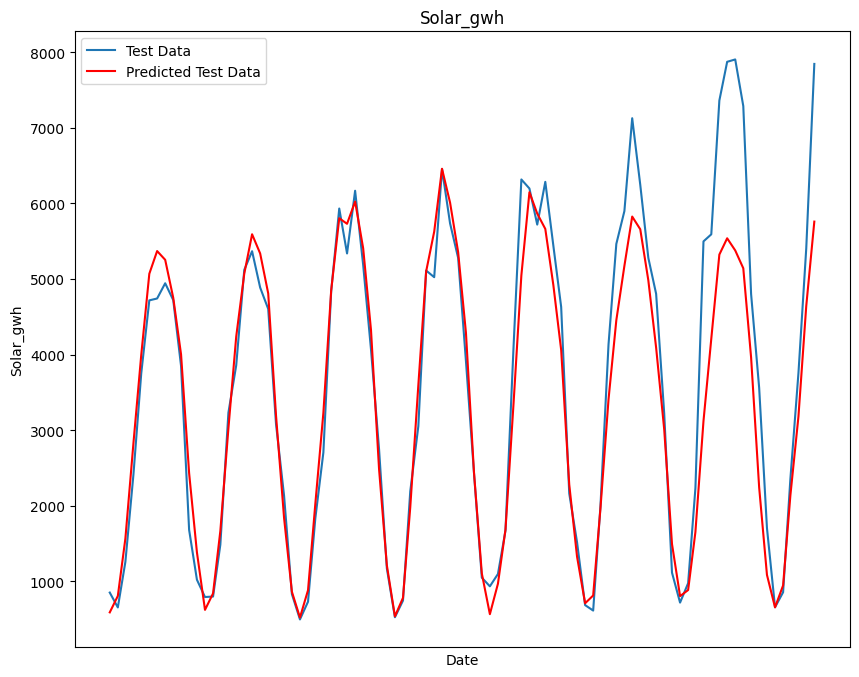

In [975]:

#data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_sunshine_duration_de_minute', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
lstm_mlvt_model(target, data_mlvt, features, lookback)

In [966]:
columns_mlvt= ['Date','Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_mlvt].copy()
data_mlvt.head()



,Date,Mean_air_temperature_de_c,Mean_precipitation_de_mm,Solar_gwh
0,2015-01-01,2.19,85.4,559.67350
1,2015-02-01,0.72,22.3,1371.00425
2,2015-03-01,5.18,55.5,2858.57725
3,2015-04-01,8.42,41.4,4435.38900
4,2015-05-01,12.34,51.7,4411.59000


Epoch 1/100
3/3 [==============================] - 2s 112ms/step - loss: 0.1742 - val_loss: 0.2620
Epoch 2/100
3/3 [==============================] - 0s 14ms/step - loss: 0.1382 - val_loss: 0.2146
Epoch 3/100
3/3 [==============================] - 0s 13ms/step - loss: 0.1033 - val_loss: 0.1665
Epoch 4/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0783 - val_loss: 0.1276
Epoch 5/100
3/3 [==============================] - 0s 16ms/step - loss: 0.0650 - val_loss: 0.1110
Epoch 6/100
3/3 [==============================] - 0s 19ms/step - loss: 0.0644 - val_loss: 0.1091
Epoch 7/100
3/3 [==============================] - 0s 15ms/step - loss: 0.0646 - val_loss: 0.1112
Epoch 8/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0607 - val_loss: 0.1176
Epoch 9/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0592 - val_loss: 0.1228
Epoch 10/100
3/3 [==============================] - 0s 14ms/step - loss: 0.0600 - val_loss: 0.1249
Epoch 11/100
3/3 [

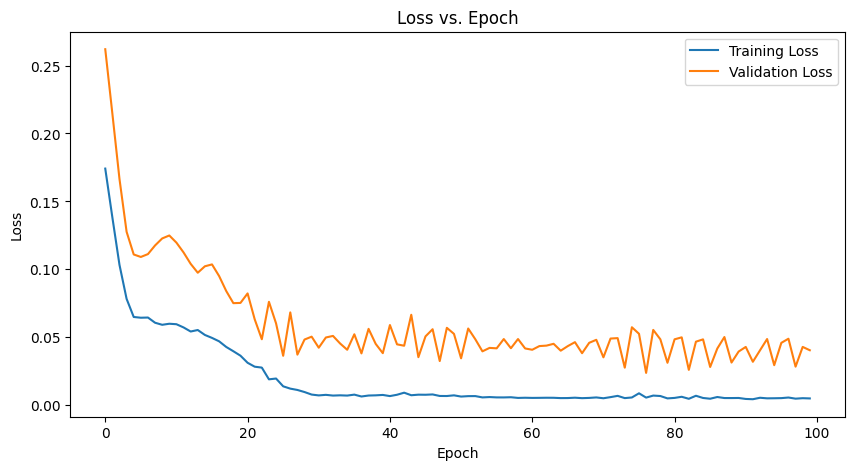

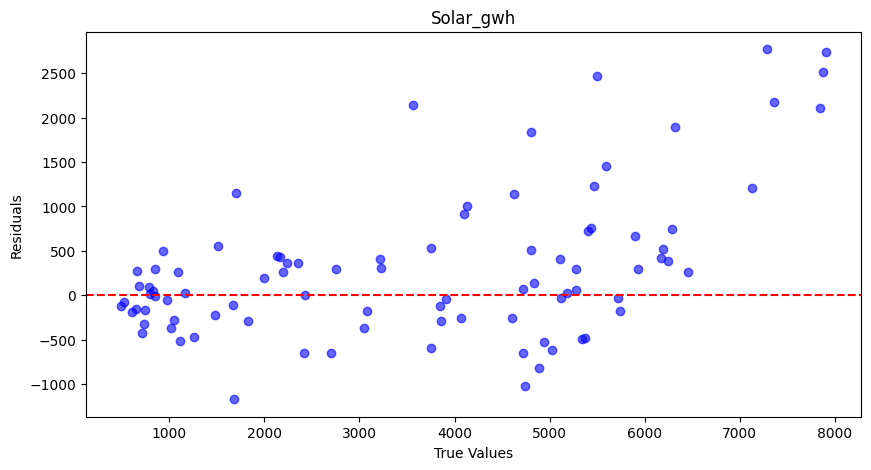

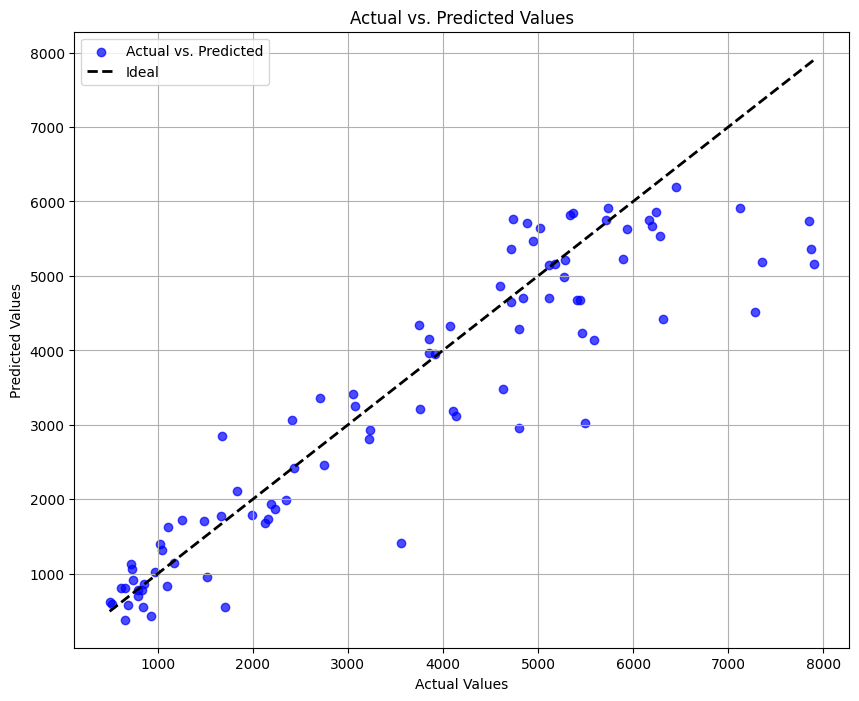

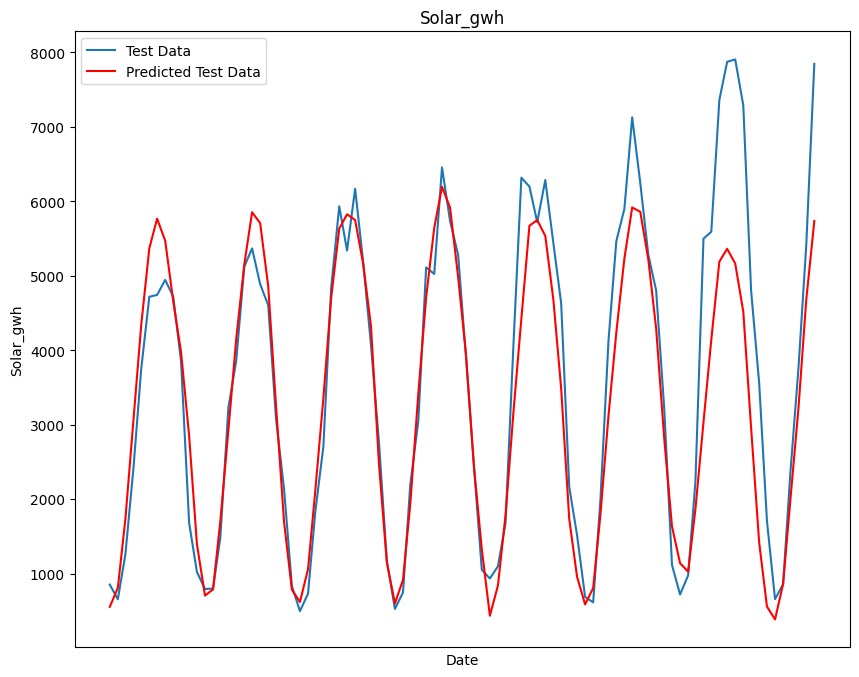

In [967]:

#data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
lstm_mlvt_model(target, data_mlvt, features, lookback)

#### Multivariate LSTM with test and train split

In [180]:
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, :-1])  # Features
        y.append(data[i + lookback - 1, -1])  # Target
    return np.array(X), np.array(y)

def lstm_mlvt_model_tst_trn(target, data_mlvt, features, lookback):
    dfs = data_mlvt[['Date'] + features + [target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)

    # Separate target and features
    target_data = dfs[[target]].values
    feature_data = dfs[features].values

    # Apply MinMax scaling with rounding
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    scaler_target = MinMaxScaler(feature_range=(0, 1))

    #feature_data_scaled = np.round(scaler_features.fit_transform(feature_data), 4)
    #target_data_scaled = np.round(scaler_target.fit_transform(target_data), 4)
    #.reshape(-1, 1)
    
    #feature_data_scaled = scaler_features.fit_transform(feature_data)
    #target_data_scaled = scaler_target.fit_transform(target_data)

    feature_data_scaled = scaler_features.fit_transform(feature_data)
    target_data_scaled = scaler_target.fit_transform(target_data)

    

    data_scaled = np.hstack((feature_data_scaled, target_data_scaled))

    X_lstm, y_lstm = create_sequences(data_scaled, target_data_scaled, lookback)

    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_lstm, y_lstm, epochs=100, batch_size=30, validation_split=0.2, verbose=1)

    y_pred_lstm = model.predict(X_lstm)

    y_pred_lstm = y_pred_lstm.reshape(-1)

    # Inverse transform the predicted and target values back to the original scale
    y_pred_lstm = scaler_target.inverse_transform(y_pred_lstm.reshape(-1, 1)).flatten()
    y_lstm = scaler_target.inverse_transform(y_lstm.reshape(-1, 1)).flatten()

    return y_lstm, y_pred_lstm

In [181]:
columns_mlvt= ['Date','Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_mlvt].copy()
#data_mlvt.head()
#

In [182]:
data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
lstm_mlvt_model_tst_trn(target, data_mlvt, features, lookback)

Epoch 1/100
3/3 [==============================] - 1s 94ms/step - loss: 0.2317 - val_loss: 0.3179
Epoch 2/100
3/3 [==============================] - 0s 12ms/step - loss: 0.1798 - val_loss: 0.2661
Epoch 3/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1422 - val_loss: 0.2300
Epoch 4/100
3/3 [==============================] - 0s 11ms/step - loss: 0.1168 - val_loss: 0.1997
Epoch 5/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0972 - val_loss: 0.1690
Epoch 6/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0781 - val_loss: 0.1395
Epoch 7/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0641 - val_loss: 0.1168
Epoch 8/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0633 - val_loss: 0.1087
Epoch 9/100
3/3 [==============================] - 0s 11ms/step - loss: 0.0673 - val_loss: 0.1088
Epoch 10/100
3/3 [==============================] - 0s 10ms/step - loss: 0.0638 - val_loss: 0.1126
Epoch 11/100
3/3 [=

(array([ 850.9295 ,  654.31425, 1257.14675, 2414.15325, 3751.5355 ,
        4716.76525, 4741.3405 , 4942.8115 , 4719.89325, 3848.414  ,
        1679.7355 , 1020.888  ,  791.9385 ,  798.42225, 1484.969  ,
        3230.5985 , 3856.85375, 5120.31225, 5366.8605 , 4886.3395 ,
        4602.78775, 3079.28725, 2130.3165 ,  831.0175 ,  495.41625,
         730.14475, 1830.4995 , 2703.90975, 4837.04525, 5931.47875,
        5337.322  , 6166.89875, 5183.46425, 4069.317  , 2748.584  ,
        1170.9555 ,  524.6635 ,  745.0215 , 2191.26725, 3051.987  ,
        5111.3625 , 5023.131  , 6454.292  , 5734.5835 , 5278.09275,
        3914.1795 , 2429.00125, 1048.334  ,  933.518  , 1097.17575,
        1671.17325, 4104.0725 , 6316.26875, 6196.537  , 5718.8275 ,
        6284.324  , 5438.543  , 4629.77925, 2162.818  , 1517.03975,
         685.01925,  612.89025, 1993.47775, 4133.17075, 5463.4095 ,
        5897.5285 , 7126.3275 , 6245.02925, 5278.4955 , 4802.81025,
        3221.2895 , 1114.24375,  718.21225,  975

In [183]:
def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, :-1])  # Features
        y.append(data[i + lookback - 1, -1])  # Target
    return np.array(X), np.array(y)

def lstm_mlvt_model1(target, data_mlvt, features, lookback, train_test_split):
    dfs = data_mlvt[['Date'] + features + [target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)

    # Separate target and features
    target_data = dfs[[target]].values
    feature_data = dfs[features].values

    # Apply MinMax scaling with rounding
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    scaler_target = MinMaxScaler(feature_range=(0, 1))

    feature_data_scaled = np.round(scaler_features.fit_transform(feature_data), 4)
    target_data_scaled = np.round(scaler_target.fit_transform(target_data), 4)

    data_scaled = np.hstack((feature_data_scaled, target_data_scaled))

    # Train-test split
    split_index = int(len(data_scaled) * train_test_split)
    train_data_scaled = data_scaled[:split_index]
    test_data_scaled = data_scaled[split_index:]

    X_train_lstm, y_train_lstm = create_sequences(train_data_scaled, target_data_scaled, lookback)
    X_test_lstm, y_test_lstm = create_sequences(test_data_scaled, target_data_scaled, lookback)

    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, validation_split=0.2, verbose=1)

    y_train_pred_lstm = model.predict(X_train_lstm)
    y_test_pred_lstm = model.predict(X_test_lstm)

    y_train_pred_lstm = y_train_pred_lstm.reshape(-1)
    y_test_pred_lstm = y_test_pred_lstm.reshape(-1)

    # Inverse transform the predicted and target values back to the original scale
    y_train_pred_lstm = scaler_target.inverse_transform(y_train_pred_lstm.reshape(-1, 1)).flatten()
    y_train_lstm = scaler_target.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten()

    y_test_pred_lstm = scaler_target.inverse_transform(y_test_pred_lstm.reshape(-1, 1)).flatten()
    y_test_lstm = scaler_target.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

    # Calculate metrics for both training and testing sets
    train_mse = mean_squared_error(y_train_lstm, y_train_pred_lstm)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train_lstm, y_train_pred_lstm)
    train_r2 = r2_score(y_train_lstm, y_train_pred_lstm)

    test_mse = mean_squared_error(y_test_lstm, y_test_pred_lstm)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test_lstm, y_test_pred_lstm)
    test_r2 = r2_score(y_test_lstm, y_test_pred_lstm)

    # Print metrics for both training and testing sets
    print("Training Mean Squared Error (MSE):", train_mse)
    print("Training Root Mean Squared Error (RMSE):", train_rmse)
    print("Training Mean Absolute Error (MAE):", train_mae)
    print("Training R-squared (R^2) Score:", train_r2)

    print("Testing Mean Squared Error (MSE):", test_mse)
    print("Testing Root Mean Squared Error (RMSE):", test_rmse)
    print("Testing Mean Absolute Error (MAE):", test_mae)
    print("Testing R-squared (R^2) Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch for training set
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot for training set
    residuals_train = y_train_lstm - y_train_pred_lstm
    plt.figure(figsize=(10, 5))
    plt.scatter(y_train_lstm, residuals_train, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(target)
    plt.show()

    # Plot actual vs. predicted values for training set
    plt.figure(figsize=(10, 8))
    plt.scatter(y_train_lstm, y_train_pred_lstm, label='Actual vs. Predicted', color='blue', alpha=0.7)
    plt.plot([y_train_lstm.min(), y_train_lstm.max()], [y_train_lstm.min(), y_train_lstm.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs. Predicted Values (Training Set)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

    # Plot actual vs. predicted values with time for testing set
    test_index = dfs.index[-len(y_test_lstm):]
    plt.figure(figsize=(10, 8))
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_test_pred_lstm, label='Predicted Test Data', color='red')
    plt.legend()
    #plt.xticks([])
    plt.title('Actual vs. Predicted Values over Time (Testing Set)')
    plt.ylabel(target)
    plt.xlabel('Date')
    plt.show()

      # Plot actual vs. predicted values with time for testing set
    plt.figure(figsize=(15, 5))
    train_index = data_mlvt.index[:split_index][-len(y_train_lstm):]
    test_index = data_mlvt.index[split_index:]
    plt.plot(data_mlvt.index, data_mlvt[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm, label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_test_pred_lstm, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_train_pred_lstm, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(target)
    plt.ylabel(target)
    plt.xlabel('Date')
    plt.show()  

    return y_train_lstm, y_train_pred_lstm, y_test_lstm, y_test_pred_lstm


In [184]:


columns_mlvt= ['Date','Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_mlvt].copy()
#data_mlvt.head()

data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
train_test_split=0.8
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
#lstm_mlvt_model_tst_trn(target, data_mlvt, features, lookback)

#y_train, y_train_pred, y_test, y_test_pred = 
results = lstm_mlvt_model2(target, data_mlvt, features, lookback, train_test_split)


#df_pred_test_multi = create_pred_df_multi(y_test_lstm, y_test_pred_lstm[target].values)
#df_pred_train_multi = create_pred_df_multi(y_train_lstm, y_train_pred_lstm[target].values)



TypeError: create_sequences() missing 1 required positional argument: 'lookback'

Epoch 1/100
2/2 [==============================] - 1s 210ms/step - loss: 0.1344 - val_loss: 0.1094
Epoch 2/100
2/2 [==============================] - 0s 17ms/step - loss: 0.0861 - val_loss: 0.0850
Epoch 3/100
2/2 [==============================] - 0s 17ms/step - loss: 0.0653 - val_loss: 0.0868
Epoch 4/100
2/2 [==============================] - 0s 16ms/step - loss: 0.0669 - val_loss: 0.0976
Epoch 5/100
2/2 [==============================] - 0s 16ms/step - loss: 0.0754 - val_loss: 0.0975
Epoch 6/100
2/2 [==============================] - 0s 16ms/step - loss: 0.0729 - val_loss: 0.0888
Epoch 7/100
2/2 [==============================] - 0s 16ms/step - loss: 0.0652 - val_loss: 0.0809
Epoch 8/100
2/2 [==============================] - 0s 16ms/step - loss: 0.0597 - val_loss: 0.0774
Epoch 9/100
2/2 [==============================] - 0s 15ms/step - loss: 0.0594 - val_loss: 0.0769
Epoch 10/100
2/2 [==============================] - 0s 15ms/step - loss: 0.0596 - val_loss: 0.0770
Epoch 11/100
2/2 [

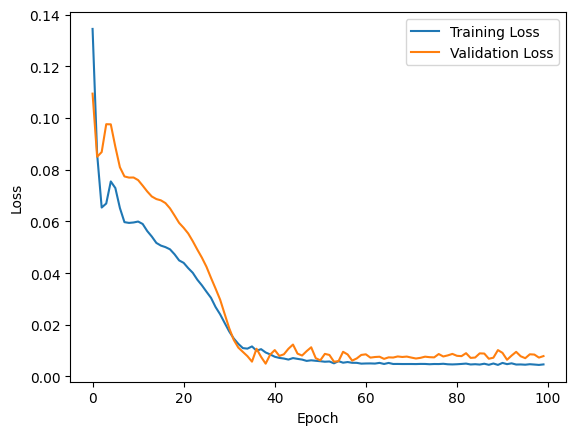

1/1 [==============================] - 0s 194ms/step


ValueError: operands could not be broadcast together with shapes (9,2) (3,) (9,2) 

In [170]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seed for reproducibility
np.random.seed(42)

# Prepare the data
columns_mlvt = ['Date', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh']
data_mlvt = data_df[columns_mlvt].copy()

# Scale the data to (0, 1) range
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_mlvt[['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh']])

# Function to create sequences
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, :-1])
        y.append(data[i + lookback, -1])
    return np.array(X), np.array(y)

# Create sequences with lookback
X, y = create_sequences(scaled_data, lookback)

# Split into training and testing sets
split_idx = int(len(X) * train_test_split)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Validation Loss and Loss vs. Epoch Curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Make predictions on the test set
y_pred = model.predict(X_test)

# Inverse transform to get original scale for X_test and y_pred
X_test_original = scaler.inverse_transform(X_test[:, -1, :-1].reshape(-1, 2))  # Reshape to match scaler
y_pred_original = scaler.inverse_transform(np.hstack((X_test_original, y_pred)))

# Inverse transform y_test to get original scale
y_test_original = scaler.inverse_transform(np.hstack((X_test_original, y_test.reshape(-1, 1))))

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_original[:, -1], y_pred_original[:, -1]))
mse = mean_squared_error(y_test_original[:, -1], y_pred_original[:, -1])
mae = mean_absolute_error(y_test_original[:, -1], y_pred_original[:, -1])
r2 = r2_score(y_test_original[:, -1], y_pred_original[:, -1])

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plot actual vs. predicted values for the test dataset
plt.figure(figsize=(10, 6))
plt.plot(y_test_original[:, -1], label='Actual')
plt.plot(y_pred_original[:, -1], label='Predicted')
plt.xlabel('Time')
plt.ylabel('Solar_gwh')
plt.legend()
plt.show()

# Create a residual plot for the test dataset
residuals = y_test_original[:, -1] - y_pred_original[:, -1]
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original[:, -1], residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Solar_gwh')
plt.ylabel('Residuals')
plt.show()

# Plot original data with training, test, and predicted data with a line at the test train split
plt.figure(figsize=(12, 6))
plt.plot(data_mlvt.index[:-lookback], data_mlvt['Solar_gwh'][:-lookback], label='Original Data', color='blue')
plt.plot(data_mlvt.index[split_idx:], y_test_original[:, -1], label='Test Data', color='green')
plt.plot(data_mlvt.index[split_idx:], y_pred_original[:, -1], label='Predicted Data', color='orange')
plt.axvline(data_mlvt.index[split_idx], color='red', linestyle='--', label='Test-Train Split')
plt.xlabel('Date')
plt.ylabel('Solar_gwh')
plt.legend()
plt.show()



Epoch 1/100
2/2 [==============================] - 1s 212ms/step - loss: 0.1508 - val_loss: 0.1361
Epoch 2/100
2/2 [==============================] - 0s 19ms/step - loss: 0.1054 - val_loss: 0.1046
Epoch 3/100
2/2 [==============================] - 0s 17ms/step - loss: 0.0765 - val_loss: 0.0933
Epoch 4/100
2/2 [==============================] - 0s 17ms/step - loss: 0.0629 - val_loss: 0.0961
Epoch 5/100
2/2 [==============================] - 0s 25ms/step - loss: 0.0679 - val_loss: 0.1028
Epoch 6/100
2/2 [==============================] - 0s 23ms/step - loss: 0.0733 - val_loss: 0.1032
Epoch 7/100
2/2 [==============================] - 0s 24ms/step - loss: 0.0730 - val_loss: 0.0976
Epoch 8/100
2/2 [==============================] - 0s 19ms/step - loss: 0.0673 - val_loss: 0.0922
Epoch 9/100
2/2 [==============================] - 0s 22ms/step - loss: 0.0634 - val_loss: 0.0884
Epoch 10/100
2/2 [==============================] - 0s 18ms/step - loss: 0.0597 - val_loss: 0.0868
Epoch 11/100
2/2 [

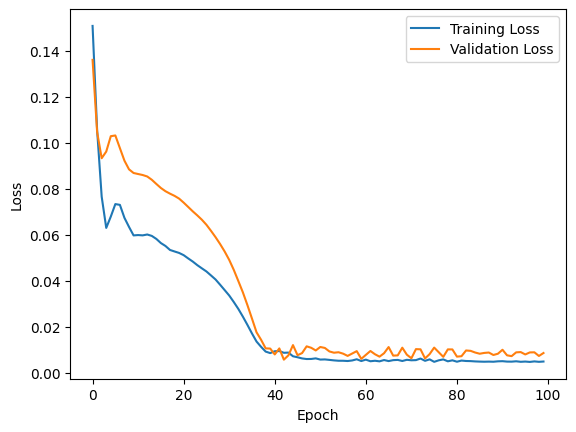

1/1 [==============================] - 0s 193ms/step
RMSE: 1692.9385244917485
MSE: 2866040.8477082984
MAE: 1407.4735791015626
R2 Score: 0.6031066635355788


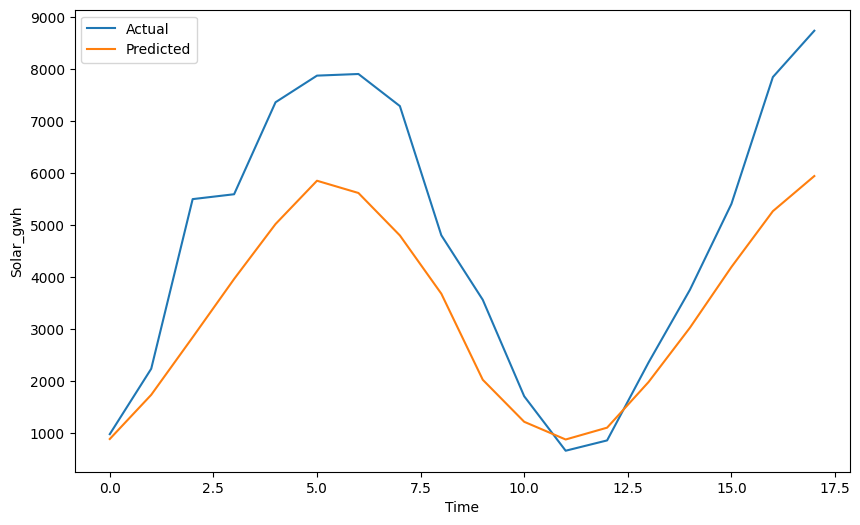

ValueError: x and y must be the same size

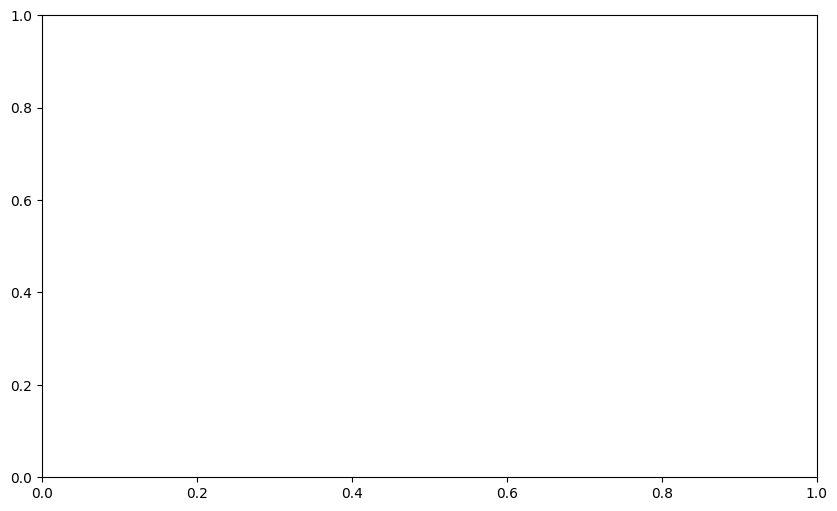

In [177]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seed for reproducibility
np.random.seed(42)

# Prepare the data
columns_mlvt = ['Date', 'Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh']
data_mlvt = data_df[columns_mlvt].copy()

# Scale the data to (0, 1) range
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_mlvt[['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh']])

# Function to create sequences
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, :-1])
        y.append(data[i + lookback, -1])
    return np.array(X), np.array(y)

# Create sequences with lookback
features = ['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
train_test_split = 0.8

X, y = create_sequences(scaled_data, lookback)

# Split into training and testing sets
split_idx = int(len(X) * train_test_split)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Build the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Validation Loss and Loss vs. Epoch Curve
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Make predictions on the test set
y_pred = model.predict(X_test)

# Inverse transform to get original scale for X_test and y_pred
X_test_reshaped = X_test[:, -1, :]
X_test_original = np.empty_like(X_test_reshaped)

for feature_idx in range(X_test_reshaped.shape[1]):
    X_test_original[:, feature_idx] = X_test_reshaped[:, feature_idx] * (scaler.data_max_[feature_idx] - scaler.data_min_[feature_idx]) + scaler.data_min_[feature_idx]

# Inverse transform y_test to get the original scale
y_test_original = y_test * (scaler.data_max_[-1] - scaler.data_min_[-1]) + scaler.data_min_[-1]

# Inverse transform y_pred to get the original scale
y_pred_original = y_pred * (scaler.data_max_[-1] - scaler.data_min_[-1]) + scaler.data_min_[-1]

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mse = mean_squared_error(y_test_original, y_pred_original)
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plot actual vs. predicted values for the test dataset
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Actual')
plt.plot(y_pred_original, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Solar_gwh')
plt.legend()
plt.show()

# Create a residual plot for the test dataset
residuals = y_test_original - y_pred_original
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Solar_gwh')
plt.ylabel('Residuals')
plt.show()

# Plot original data with training, test, and predicted data with a line at the test-train split
plt.figure(figsize=(12, 6))
plt.plot(data_mlvt.index[:-split_idx], data_mlvt['Solar_gwh'][:-split_idx], label='Original Data', color='blue')
plt.plot(data_mlvt.index[split_idx:], y_test_original, label='Test Data', color='green')
plt.plot(data_mlvt.index[split_idx:], y_pred_original, label='Predicted Data', color='orange')
plt.axvline(data_mlvt.index[split_idx], color='red', linestyle='--', label='Test-Train Split')
plt.xlabel('Date')
plt.ylabel('Solar_gwh')
plt.legend()
plt.show()


In [163]:


def create_sequences(data, target, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback, :-1])  # Features
        y.append(data[i + lookback - 1, -1])  # Target
    return np.array(X), np.array(y)

def lstm_mlvt_model2(target, data_mlvt, features, lookback, train_test_split=0.8):
    data_mlvt['Date'] = pd.to_datetime(data_mlvt['Date']).dt.strftime('%Y-%m-%d')

    dfs = data_mlvt[['Date'] + features + [target]]
    dfs['Date'] = pd.to_datetime(dfs['Date'])
    dfs.set_index('Date', inplace=True)

    # Separate target and features
    target_data = dfs[[target]].values
    feature_data = dfs[features].values

    # Apply MinMax scaling with rounding
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    scaler_target = MinMaxScaler(feature_range=(0, 1))

    feature_data_scaled = np.round(scaler_features.fit_transform(feature_data), 4)
    target_data_scaled = np.round(scaler_target.fit_transform(target_data), 4)

    data_scaled = np.hstack((feature_data_scaled, target_data_scaled))

    # Train-test split
    split_index = int(len(data_scaled) * train_test_split)
    train_data_scaled = data_scaled[:split_index]
    test_data_scaled = data_scaled[split_index:]

    # Reshape the data to match the LSTM model input
    num_features = len(features)
    X_train_lstm, y_train_lstm = create_sequences(train_data_scaled, target_data_scaled, lookback)
    X_test_lstm, y_test_lstm = create_sequences(test_data_scaled, target_data_scaled, lookback)

    print('Size before prediction')
    print('y_train_lstm =', y_train_lstm.shape)
    print('y_test_lstm =', y_test_lstm.shape)
    print('X_train_lstm =', X_train_lstm.shape)
    print('X_test_lstm =', X_test_lstm.shape)

    es = EarlyStopping(mode='min', verbose=1, patience=20)

    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, num_features), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=30, verbose=2, callbacks=[es])

    y_train_pred_lstm = model.predict(X_train_lstm)
    y_test_pred_lstm = model.predict(X_test_lstm)

    y_train_pred_lstm = y_train_pred_lstm.flatten()
    y_test_pred_lstm = y_test_pred_lstm.flatten()

    # Inverse transform the predicted and target values back to the original scale
    y_train_pred_lstm = scaler_target.inverse_transform(y_train_pred_lstm.reshape(-1, 1)).flatten()
    y_train_lstm = scaler_target.inverse_transform(y_train_lstm.reshape(-1, 1)).flatten()

    y_test_pred_lstm = scaler_target.inverse_transform(y_test_pred_lstm.reshape(-1, 1)).flatten()
    y_test_lstm = scaler_target.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

    # Calculate metrics for both training and testing sets
    train_mse = mean_squared_error(y_train_lstm, y_train_pred_lstm)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train_lstm, y_train_pred_lstm)
    train_r2 = r2_score(y_train_lstm, y_train_pred_lstm)

    test_mse = mean_squared_error(y_test_lstm, y_test_pred_lstm)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test_lstm, y_test_pred_lstm)
    test_r2 = r2_score(y_test_lstm, y_test_pred_lstm)

    # Print metrics for both training and testing sets
    print("Training Mean Squared Error (MSE):", train_mse)
    print("Training Root Mean Squared Error (RMSE):", train_rmse)
    print("Training Mean Absolute Error (MAE):", train_mae)
    print("Training R-squared (R^2) Score:", train_r2)

    print("Testing Mean Squared Error (MSE):", test_mse)
    print("Testing Root Mean Squared Error (RMSE):", test_rmse)
    print("Testing Mean Absolute Error (MAE):", test_mae)
    print("Testing R-squared (R^2) Score:", test_r2)

    # Plot loss versus epoch and validation loss versus epoch for training set
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()

    # Create a residual plot for training set
    residuals_train = y_train_lstm - y_train_pred_lstm
    plt.figure(figsize=(10, 5))
    plt.scatter(y_train_lstm, residuals_train, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(target)
    plt.show()

    # Plot actual vs. predicted values for training set
    plt.figure(figsize=(10, 8))
    plt.scatter(y_train_lstm, y_train_pred_lstm, label='Actual vs. Predicted (Train)', color='blue', alpha=0.7)
    plt.plot([y_train_lstm.min(), y_train_lstm.max()], [y_train_lstm.min(), y_train_lstm.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs. Predicted Values (Training Set)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

    # Plot data
    plt.figure(figsize=(12, 6))
    plt.plot(data_mlvt['Date'].iloc[-len(y_test_lstm):], y_test_lstm, label='Test Data (Actual)', color='blue', alpha=0.8)
    plt.plot(data_mlvt['Date'].iloc[-len(y_test_lstm):], y_test_pred_lstm, label='Test Data (Predicted)', color='red', alpha=0.8)
    plt.plot(data_mlvt['Date'].iloc[-len(y_train_lstm):], y_train_lstm, label='Train Data (Actual)', color='green', alpha=0.6)
    plt.plot(data_mlvt['Date'].iloc[-len(y_train_lstm):], y_train_pred_lstm, label='Train Data (Predicted)', color='orange', alpha=0.6)
    plt.xlabel('Date')
    plt.ylabel('Solar_gwh')
    plt.title('Actual vs. Predicted Values (Train and Test Set)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

    # Plot data
    plt.figure(figsize=(12, 6))
    plt.plot(data_mlvt['Date'], data_mlvt[target], label='Historical Data', color='gray', alpha=0.6)
    plt.plot(data_mlvt['Date'].iloc[-len(y_test_lstm):], y_test_lstm, label='Test Data (Actual)', color='blue', alpha=0.8)
    plt.plot(data_mlvt['Date'].iloc[-len(y_test_lstm):], y_test_pred_lstm, label='Test Data (Predicted)', color='red', alpha=0.8)
    plt.plot(data_mlvt['Date'].iloc[-len(y_train_lstm):], y_train_lstm, label='Train Data (Actual)', color='green', alpha=0.6)
    plt.plot(data_mlvt['Date'].iloc[-len(y_train_lstm):], y_train_pred_lstm, label='Train Data (Predicted)', color='orange', alpha=0.6)
    plt.axvline(x=data_mlvt['Date'].iloc[split_index], color='gray', linestyle='--', label='Test-Train Split')
    plt.xlabel('Date')
    plt.ylabel('Solar_gwh')
    plt.title('Actual vs. Predicted Values (Train and Test Set)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

     # Plot data
    plt.figure(figsize=(12, 6))
    plt.plot(data_mlvt['Date'], data_mlvt[target], label='Historical Data', color='gray', alpha=0.6)
    plt.plot(data_mlvt['Date'].iloc[-len(y_test_lstm):], y_test_lstm, label='Test Data (Actual)', color='blue', alpha=0.8)
    plt.plot(data_mlvt['Date'].iloc[-len(y_test_lstm):], y_test_pred_lstm, label='Test Data (Predicted)', color='red', alpha=0.8)
    plt.plot(data_mlvt['Date'].iloc[-len(y_train_lstm):], y_train_lstm, label='Train Data (Actual)', color='green', alpha=0.6)
    plt.plot(data_mlvt['Date'].iloc[-len(y_train_lstm):], y_train_pred_lstm, label='Train Data (Predicted)', color='orange', alpha=0.6)
    plt.axvline(x=data_mlvt['Date'].iloc[split_index], color='gray', linestyle='--', label='Test-Train Split')
    
    # Set x-axis ticks and limits
    plt.xticks(rotation=45)
    plt.xlim(data_mlvt['Date'].iloc[0], data_mlvt['Date'].iloc[-1])

    plt.xlabel('Date')
    plt.ylabel('Solar_gwh')
    plt.title('Actual vs. Predicted Values (Train and Test Set)')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ... (previous code)

# Reshape the data to match the LSTM model input
    num_features = len(features)
    lookback_train = lookback + 1  # Adjusting lookback to include target value

    X_train_lstm, y_train_lstm = create_sequences(train_data_scaled, target_data_scaled, lookback_train)
    X_test_lstm, y_test_lstm = create_sequences(test_data_scaled, target_data_scaled, lookback_train)

    # ... (previous code)

    # Inverse transform the predicted and target values back to the original scale
    y_train_pred_lstm_orig = scaler_target.inverse_transform(y_train_pred_lstm.reshape(-1, 1)).flatten()
    y_train_lstm_orig = scaler_target.inverse_transform(y_train_lstm[:, -1].reshape(-1, 1)).flatten()

    y_test_pred_lstm_orig = scaler_target.inverse_transform(y_test_pred_lstm.reshape(-1, 1)).flatten()
    y_test_lstm_orig = scaler_target.inverse_transform(y_test_lstm[:, -1].reshape(-1, 1)).flatten()

    # Retrieve original dates
    train_dates = data_mlvt.index[lookback_train:split_index]  # Adjusted to match the reshaped data
    test_dates = data_mlvt.index[split_index+lookback_train-1:]

    # Create plots
    plt.figure(figsize=(12, 6))
    plt.plot(data_mlvt.index, data_mlvt[target], label='Historical Data')
    plt.axvline(train_dates[-1], color='r', linestyle='--', label='Test-Train Split')
    plt.plot(train_dates, y_train_lstm_orig, label='Train Data (Original)')
    plt.plot(test_dates, y_test_lstm_orig, label='Test Data (Original)')
    plt.plot(train_dates, y_train_pred_lstm_orig, label='Train Data (Predicted)')  # Removed lookback from train_dates
    plt.plot(test_dates, y_test_pred_lstm_orig, label='Test Data (Predicted)')  # Removed lookback from test_dates
    plt.xlabel('Date')
    plt.ylabel('Target Value')
    plt.title('Original Data vs. Predicted Data')
    plt.legend()
    plt.grid(True)
    plt.show()



    return y_train_lstm, y_train_pred_lstm, y_test_lstm, y_test_pred_lstm


Size before prediction
y_train_lstm = (69,)
y_test_lstm = (9,)
X_train_lstm = (69, 12, 2)
X_test_lstm = (9, 12, 2)
Epoch 1/100
3/3 - 1s - loss: 0.1795 - 908ms/epoch - 303ms/step
Epoch 2/100
3/3 - 0s - loss: 0.1578 - 17ms/epoch - 6ms/step
Epoch 3/100
3/3 - 0s - loss: 0.1417 - 15ms/epoch - 5ms/step
Epoch 4/100
3/3 - 0s - loss: 0.1243 - 14ms/epoch - 5ms/step
Epoch 5/100
3/3 - 0s - loss: 0.1064 - 14ms/epoch - 5ms/step
Epoch 6/100
3/3 - 0s - loss: 0.0837 - 15ms/epoch - 5ms/step
Epoch 7/100
3/3 - 0s - loss: 0.0647 - 15ms/epoch - 5ms/step
Epoch 8/100
3/3 - 0s - loss: 0.0722 - 15ms/epoch - 5ms/step
Epoch 9/100
3/3 - 0s - loss: 0.0689 - 13ms/epoch - 4ms/step
Epoch 10/100
3/3 - 0s - loss: 0.0609 - 16ms/epoch - 5ms/step
Epoch 11/100
3/3 - 0s - loss: 0.0614 - 12ms/epoch - 4ms/step
Epoch 12/100
3/3 - 0s - loss: 0.0626 - 14ms/epoch - 5ms/step
Epoch 13/100
3/3 - 0s - loss: 0.0617 - 13ms/epoch - 4ms/step
Epoch 14/100
3/3 - 0s - loss: 0.0596 - 13ms/epoch - 4ms/step
Epoch 15/100
3/3 - 0s - loss: 0.0581 

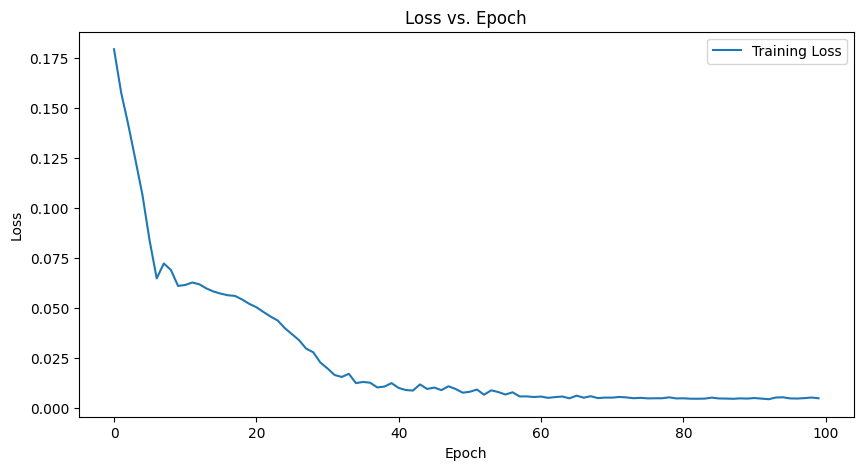

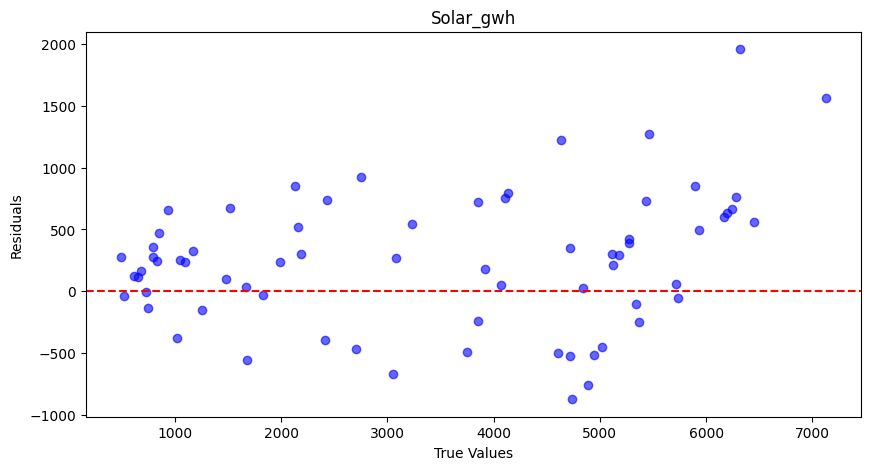

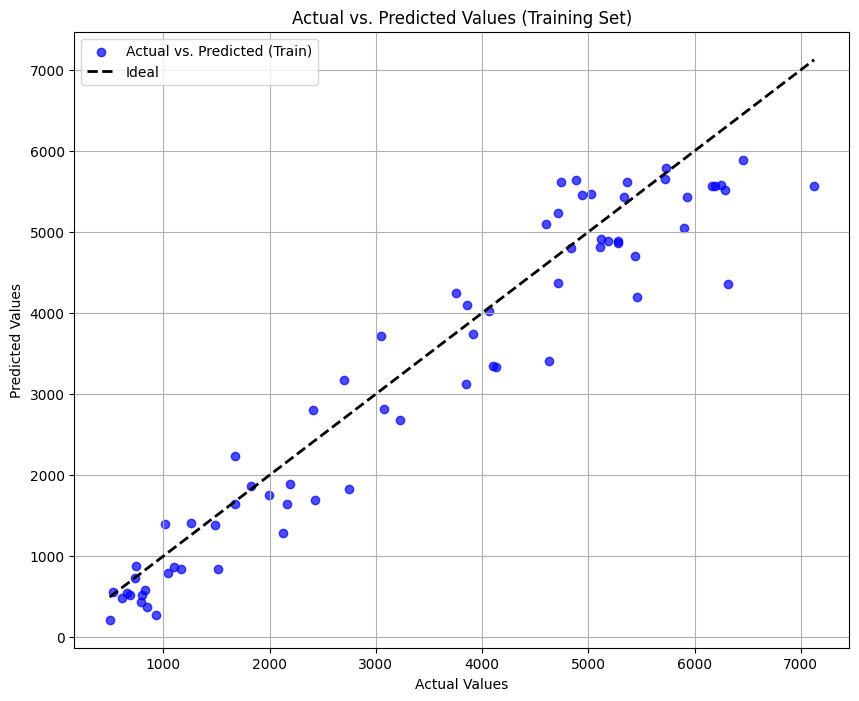

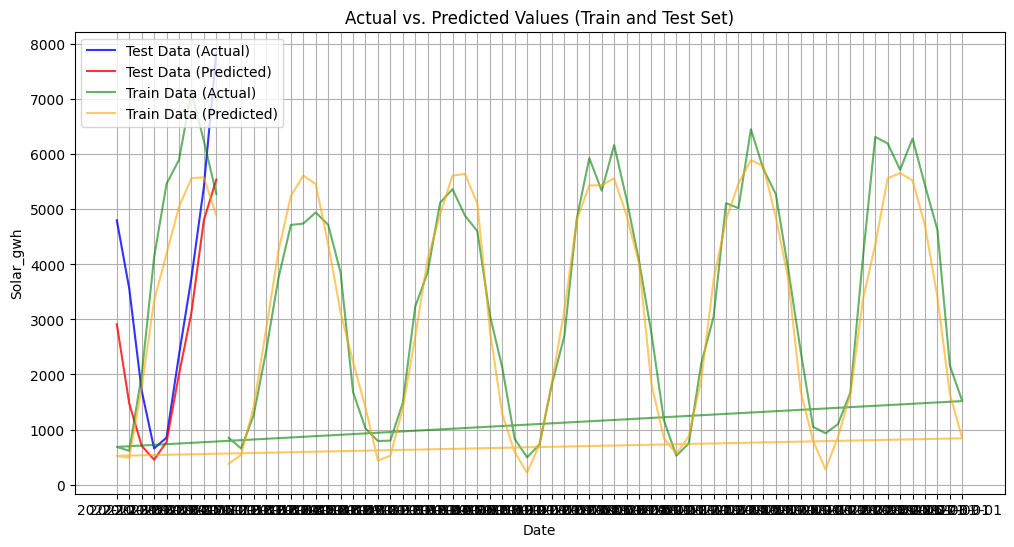

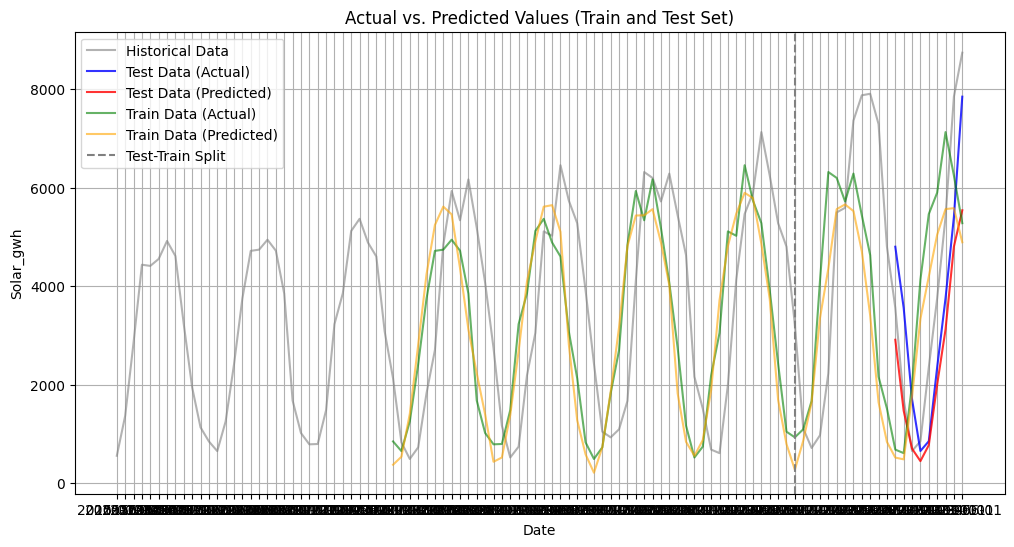

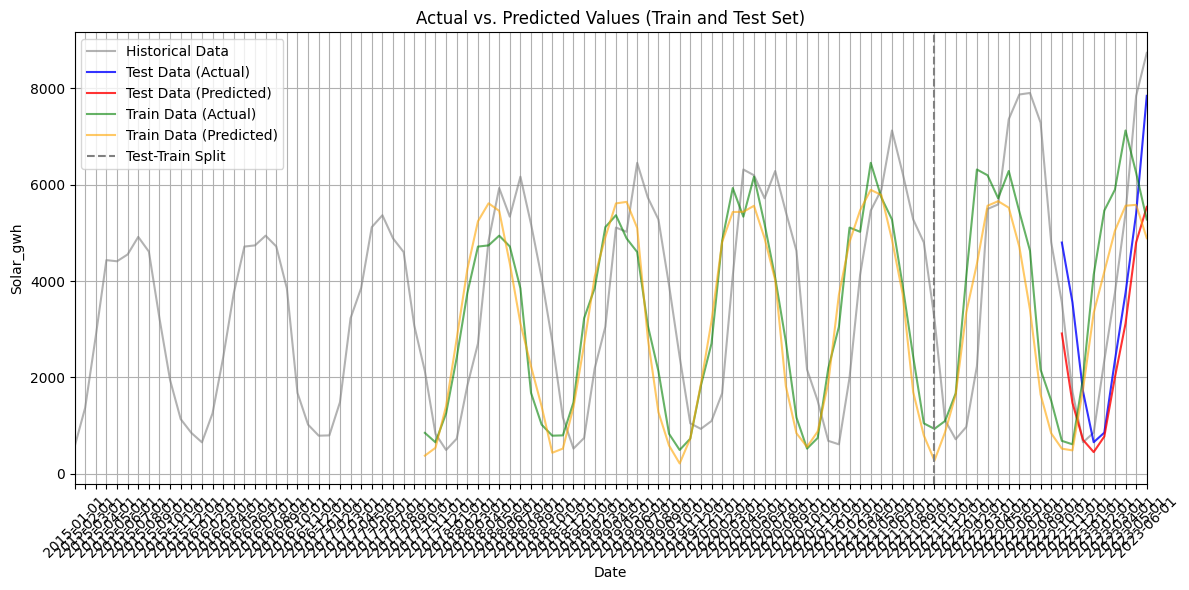

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [164]:


columns_mlvt= ['Date','Mean_air_temperature_de_c', 'Mean_precipitation_de_mm', 'Solar_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_mlvt].copy()
#data_mlvt.head()

data = data_df.copy()
#target = 'Total_energy_generation_gwh'
features = ['Mean_air_temperature_de_c', 'Mean_precipitation_de_mm']
target = 'Solar_gwh'
lookback = 12
train_test_split=0.8
#features =  ['Mean_sunshine_duration_de_minute']#['Mean_air_temperature_de_c', 'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm']
#lstm_mlvt_model_tst_trn(target, data_mlvt, features, lookback)

#y_train, y_train_pred, y_test, y_test_pred = 
results = lstm_mlvt_model2(target, data_mlvt, features, lookback, train_test_split)


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [12]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [13]:
data_df_gwh = data_df_mwh.copy()

In [14]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [15]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [16]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [17]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [18]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [19]:

data_df= data_df_gwh.copy()

In [20]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [21]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [23]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [18]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

main_0  = 'Total_energy_generation_gwh' # This is only for energy
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [37]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [38]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

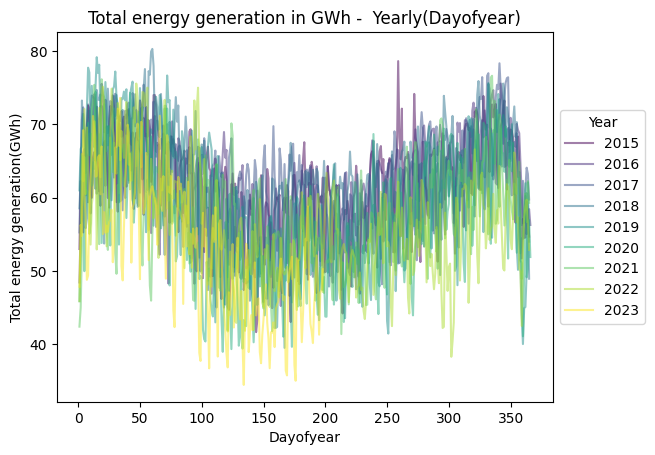

In [40]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [41]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [46]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result
    #df_dt.head()

In [48]:
# Rolling mean
# window =
#df_dt[target]=data_df[target].rolling(window=365).mean() 
#df_dt = df_dt.dropna() #df_dt = df_dt.dropna(how='all')#(axis=0)
#df_dt = df_dt.dropna(axis=0)
# Reset index after drop
#df_dt=df_dt.dropna().reset_index(drop=True)
#df_dt.head()

In [52]:
#df_dt.loc[(df_dt.index > '2023-01-01') & (df_dt.index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target, title= 'Data of last year', label = '2023 data')
#ax.legend(['2023 data'])
#plt.show()

In [53]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df
#df_dt = create_features(df_dt)
#df_dt.head()

In [57]:
dfs = data_df[['Date', target]]

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_81468/1283765561.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dfs[target])


Text(0.5, 1.0, 'Energy Distribution')

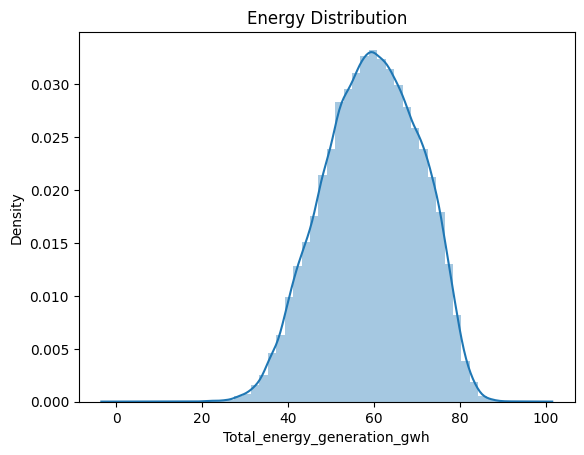

In [60]:
sns.distplot(dfs[target])
plt.title("Energy Distribution")
#sns.distplot(dfs['Solar_gwh'])
#plt.title("Solae Energy Distribution")

In [61]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [80]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Year')
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Year')

In [81]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Month')
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Month')

In [82]:
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
#average_lineplot_no_group_Wind_onshore(df=data_df, y='Wind_onshore_gwh', x="Date", time='Month')
#average_lineplot_no_group_Wind_offshore(df=data_df, y= 'Wind_offshore_gwh', x="Date", time='Month')

In [69]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh'] #'Total_other_renewable_gwh'
target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_to_keep].copy()
data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


In [83]:
def average_lineplots(df, y_values, x='Date', time='Year'):
    fig, axes = plt.subplots(len(y_values), 1, figsize=(10, 5 * len(y_values)))

    for idx, y in enumerate(y_values):
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        ax = axes[idx]
        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')
        ax.set(title='', ylabel=y_label_target0)
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
#average_lineplots(df=data_df, y_values=['Total_energy_generation_gwh', 'Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

In [20]:
def average_lineplot_no_group(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])

    plt.show()

average_lineplot_no_group(df=data_df, y_values=['Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')   
#average_lineplot_no_group(df=data_df, y_values=['Total_energy_generation_gwh', 'Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot_no_group(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

NameError: name 'data_df' is not defined

#### Multivariate LSTM

#### Working code

In [85]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh'] #'Total_other_renewable_gwh'
target = 'Total_energy_generation_gwh'
features= ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh']
data_mlvt = data_df[columns_to_keep].copy()
data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000
